In [1]:
import empyrical as ep
import pandas as pd

from pathlib import Path
import qlib
from qlib.data import D
from qlib.utils import init_instance_by_config
from typing import List, Tuple, Dict
from scr.turnover_coefficient_ops import ARC, VRC, SRC, KRC
from scr.cyq_ops import (
    CYQK_C_T,
    CYQK_C_U,
    CYQK_C_TN,
    ASR_T,
    ASR_U,
    ASR_TN,
    CKDW_T,
    CKDW_U,
    CKDW_TN,
    PRP_T,
    PRP_U,
    PRP_TN,
)
from scr.factor_analyze import clean_factor_data, get_factor_group_returns
from scr.qlib_workflow import run_model, get_dataset_config, get_tsdataset_config
from scr.plotting import plot_dist_chips, model_performance_graph, report_graph

import matplotlib.pyplot as plt

# plt中文显示
plt.rcParams["font.sans-serif"] = ["SimHei"]
# plt显示负号
plt.rcParams["axes.unicode_minus"] = False

In [2]:
custom_ops: List = [ARC, VRC, SRC, KRC, CYQK_C_T, CYQK_C_U, CYQK_C_TN,
                    ASR_T, ASR_U, ASR_TN, CKDW_T, CKDW_U, CKDW_TN, PRP_T, PRP_U, PRP_TN]
qlib.init(provider_uri="qlib_data",
          region="cn", custom_ops=custom_ops)

[6020:MainThread](2023-04-12 09:31:33,351) INFO - qlib.Initialization - [config.py:416] - default_conf: client.
[6020:MainThread](2023-04-12 09:31:33,354) INFO - qlib.Initialization - [__init__.py:74] - qlib successfully initialized based on client settings.
[6020:MainThread](2023-04-12 09:31:33,354) INFO - qlib.Initialization - [__init__.py:76] - data_path={'__DEFAULT_FREQ': WindowsPath('D:/WorkSpace/QuantsPlaybook/B-因子构建类/筹码因子/qlib_data')}


# 根据前景理论的筹码因子构建

## 交易行为的非对称性

行为金融学认为，股票的价格并不由股票的内在价值所决定，还很大程度上受投资者主体的行为和心理的影响。换句话说，如果投资者的决策过程存在规律或者特定的话，我们便可以利用这种“人性的弱点”来寻找股票市场的定价错误。

诺贝尔经济学奖得主卡尼曼曾提出前景理论来描述人们的风险决策行为，其理论有三点结论：处于收益状态时，人们往往小心翼翼、厌恶风险、喜欢见好就收；处于亏损状态时，人们往往会极不甘心，宁愿承受更大的风险来赌一把；白捡的100元所带来的快乐，难以抵消丢失100元所带来的痛苦。

当前景理论应用在股票市场时，便成了股票市场的处置效应，即：投资者急于卖出盈利的股票，而不愿意卖出亏损的股票；损失股票的持有时间比收益股票的持有时间长；当股票的价格接近投资者的购买价格的时候，投资者效用会发生剧烈改变。


本文希望通过量化的工具来挖掘处置效应导致的市场定价错误，从而得到不一般基本面分析和资金面分析所不能涉及的Alpha信息，并且我们有理由相信这种基于“人性的弱点”的Alpha是显著而且具有长期有效性的。

## 筹码分布的计算

通过上面的分析我们可以知道，若我们知道各个投资者的购买成本，那么我们就可以分析出来股票市场是否真的存在处置效应，并可以以此指导我们进行投资。但是除了交易所，没有人可以知道其他投资者的购买成本的。因此，此处我们根据市场上已有的价格与成交数据近似的代表股票市场投资者的购买成本以及购买数量，以此计算股票的筹码分布。

**调整换手率**

我们利用成均价与换手率来近似计算股票的筹码分布情况。具体的计算细节为：

1. 先确定目标交易日；以表1为例，周五为我们的目标交易日；
2. 换手率的路径依赖调整；以表1为例，周四交易的20%的股份在周五还没有被重新交易的股份为20%×（1-20%）=16%；同理周三交易的20%的股份在周五还没有被重新交易的股份为20%×（1-20%）×（1-20%）=13%；
3. 换手率归一化，根据调整换手率的和对每日的调整换手率进行归一化；
   
|日期|成交均价|相对收益|换手率|调整换手率|归一化换手率|
|--|--|--|--|--|--|
|周一|10|1-10/13=0.23|0.01|0.01*(1-0.05)*(1-0.08)*(1-0.02)*(1-0.03)=0.0083|0.0601|
|周二|11|1-11/13=0.15|0.005|0.005*(1-0.08)*(1-0.02)*(1-0.03)=0.0044|0.0319|
|周三|12|1-12/13=0.07|0.08|0.08*(1-0.02)*(1-0.03)=0.0760|0.5503|
|周四|10|1-10/13=0.23|0.02|0.02*(1-0.03)=0.0194|0.1405|
|周五|13|1-13/13=0.00|0.03|0.03|0.2172|
|总和|||0.145|0.1381|1|

可以看出这种筹码分布的计算方法，有一个很强的假设在于每一日的换手平均化到之前的每一天。即按上表来说，周一的成交量，在周二有0.5%被卖出，周三在周二卖出的基础上再有8%被卖出，周四周五同理。对于周五的3%换手来说，是周四成交的数量的2%加上周三成交的数量但在周四未卖出的3%，一直往前加到周一。

**显然，这离真实的筹码分布还有一定的距离，成交量不可能是简单的平摊到之前的每一天**。但我们得基于此假设继续研究，我们以此为近似筹码分布。

## 筹码分布的四个代理变量

给定任意一只股票，假设该股票在t日的成交均价为$P_t$，在t-1日的成交均价为$P_{t−1}$，同理在t-n日的成交均价为$P_{t−n}$。如果我们以t日为目标日计算筹码分布的话，则任意一日n(1≤n≤60)被交易的股份的相对资产收益（注意：相对资本收益并不是指投资回报）为：

$$RC_{t}=\frac{P_t-P_{t-n}}{P_t}$$

假设股票在t日得换手率为$TR_{t}$,在t-n日的换手率为$TR_{t-n}$。因此，根据我们上述换手率归一化的方法，目标日归一化换手率$TR\_W_{n}$为:
$$ATR_{t} = TR_{t} + TR_{t-1}*(1-TR_{t}) + TR_{t-2}*(1-TR_{t-1})*(1-TR_{t})+\dots + TR_{t-n}*(1-TR_{t-n-1})*\dots*(1-TR_{t})$$
$$TR\_W_{t}=\frac{ATR_{t}}{\sum^{n}_{n=1}ATR_{n}}$$

根据相对资本收益以及调整换手率,我们可以构建筹码分布的均值,方差,偏度和峰度四个代理变量:

$$ARC_{t}=\sum^{n}_{n=1}TR\_W_{t}*RC_{t}$$

ARC>0表示筹码处于平均盈利状态；ARC<0表示筹码处于平均亏损状态；

$$VRC_{t}=\frac{\sum^{n}_{n=1}n*TR\_W_{t}*(RC_{t}-ARC_{t})^{2}}{n-1}$$

VRC特别大表示筹码特别的分散；VRC特别小表示筹码比较集中；

$$SRC_{t}=\frac{\sum^{n}_{n=1}n*TR\_W_{t}*(RC_{t}-ARC_{t})^{3}}{VRC^{1.5}_{t}*(n-1)}$$

SRC>0表示筹码分布不对称且右偏，即有一部分投资者的收益特别高；SRC<0表示筹码分布不对称且左偏，即有一部分投资者亏损特别严重；

$$KRC_{t}=\frac{\sum^{n}_{n=1}n*TR\_W_{t}*(RC_{t}-ARC_{t})^{4}}{VRC^{2}_{t}*(n-1)}$$

KRC特别大表示筹码分布里面盈亏分化很强，要么盈利很多，要么亏损很多，处于小赢小亏状态的筹码非常少；KRC特别小则表现盈亏分化很小，筹码处于小赢小亏的状态；

**n默认为60日**

## 因子构建

In [35]:
###################################
# 参数配置
###################################
# 数据处理器参数配置：整体数据开始结束时间，训练集开始结束时间，股票池
TARIN_PERIODS: Tuple = ("2014-01-01", "2017-12-31")
VALID_PERIODS: Tuple = ("2018-01-01", "2020-12-31")
TEST_PERIODS: Tuple = ("2021-01-01", "2023-02-17")


dataset_config: Dict = get_dataset_config(
    "pool", TARIN_PERIODS, VALID_PERIODS, TEST_PERIODS, "TurnCoeffChips"
)


if Path("factor_data/turnovercoeff_dataset.pkl").exists():
    import pickle

    with open("factor_data/turnovercoeff_dataset.pkl", "rb") as f:
        turncoeff_dataset = pickle.load(f)
else:
    # 实例化数据集，从基础行情数据计算出的包含所有特征（因子）和标签值的数据集。
    turncoeff_dataset = init_instance_by_config(dataset_config)  # 类型DatasetH

    # 保存数据方便后续使用
    turncoeff_dataset.config(dump_all=True, recursive=True)
    turncoeff_dataset.to_pickle(
        path="factor_data/turnovercoeff_dataset.pkl", dump_all=True
    )

record_dict: Dict = run_model(
    turncoeff_dataset,
    "transformer",
    start_time=TEST_PERIODS[0],
    end_time=TEST_PERIODS[1],
    model_kw={"d_feat": 4, "num_layers": 16, "nhead": 8, "method": "normal"},
    experiment_name="turncoeffchips",
    trained_model="trained_model.pkl",
)

[6020:MainThread](2023-04-12 09:54:56,101) INFO - qlib.TransformerModel - [pytorch_transformer.py:64] - Naive Transformer:
batch_size : 8192
device : cuda:0


[09:54:56] 实验名:turncoeffchips,训练模型:trained_model.pkl,开始运行...                        ]8;id=978253;file://d:\WorkSpace\QuantsPlaybook\B-因子构建类\筹码因子\scr\qlib_workflow.py\qlib_workflow.py]8;;\:]8;id=483844;file://d:\WorkSpace\QuantsPlaybook\B-因子构建类\筹码因子\scr\qlib_workflow.py#303\303]8;;\

[6020:MainThread](2023-04-12 09:54:56,146) INFO - qlib.workflow - [exp.py:258] - Experiment 3 starts running ...
[6020:MainThread](2023-04-12 09:54:56,163) INFO - qlib.workflow - [recorder.py:341] - Recorder b6fb35b51626493f835c86c7d8a2b1b3 starts running under Experiment 3 ...
[6020:MainThread](2023-04-12 09:54:56,466) INFO - qlib.TransformerModel - [pytorch_transformer.py:190] - training...
[6020:MainThread](2023-04-12 09:54:56,467) INFO - qlib.TransformerModel - [pytorch_transformer.py:194] - Epoch0:
[6020:MainThread](2023-04-12 09:54:56,467) INFO - qlib.TransformerModel - [pytorch_transformer.py:195] - training...
[6020:MainThread](2023-04-12 09:55:01,802) INFO - qlib.TransformerModel - [pytorch_transformer.py:197] - evaluating...
[6020:MainThread](2023-04-12 09:55:04,163) INFO - qlib.TransformerModel - [pytorch_transformer.py:200] - train -0.945833, valid -0.984858
[6020:MainThread](2023-04-12 09:55:04,174) INFO - qlib.TransformerModel - [pytorch_transformer.py:194] - Epoch1:
[602

'The following are prediction results of the TransformerModel model.'
                          score
datetime   instrument          
2021-01-04 000001.SZ  -0.006654
           000002.SZ  -0.001295
           000063.SZ  -0.004282
           000066.SZ  -0.014396
           000069.SZ  -0.001880
{'IC': 0.018862776648205487,
 'ICIR': 0.11762023484953855,
 'Rank IC': 0.01813822724473709,
 'Rank ICIR': 0.10418792127563933}


[6020:MainThread](2023-04-12 09:56:41,735) INFO - qlib.backtest caller - [__init__.py:93] - Create new exchange
[6020:MainThread](2023-04-12 09:57:24,767) WARNING - qlib.online operator - [exchange.py:219] - $open field data contains nan.
[6020:MainThread](2023-04-12 09:57:24,769) WARNING - qlib.online operator - [exchange.py:219] - $open field data contains nan.
[6020:MainThread](2023-04-12 09:57:27,338) WARNING - qlib.BaseExecutor - [executor.py:121] - `common_infra` is not set for <qlib.backtest.executor.SimulatorExecutor object at 0x000001D7B2F8EA60>


...

d:\anaconda3\envs\qlib_env\lib\site-packages\qlib\utils\index_data.py:482: RuntimeWarning: Mean of empty slice
  return np.nanmean(self.data)
d:\anaconda3\envs\qlib_env\lib\site-packages\qlib\utils\index_data.py:482: RuntimeWarning: Mean of empty slice
  return np.nanmean(self.data)
d:\anaconda3\envs\qlib_env\lib\site-packages\qlib\utils\index_data.py:482: RuntimeWarning: Mean of empty slice
  return np.nanmean(self.data)
[6020:MainThread](2023-04-12 09:57:30,053) INFO - qlib.workflow - [record_temp.py:505] - Portfolio analysis record 'port_analysis_1day.pkl' has been saved as the artifact of the Experiment 3


'The following are analysis results of benchmark return(1day).'
                       risk
mean              -0.000424
std                0.012109
annualized_return -0.101027
information_ratio -0.540792
max_drawdown      -0.473379
'The following are analysis results of the excess return without cost(1day).'
                       risk
mean               0.001020
std                0.009477
annualized_return  0.242648
information_ratio  1.659656
max_drawdown      -0.115616
'The following are analysis results of the excess return with cost(1day).'
                       risk
mean               0.000595
std                0.009488
annualized_return  0.141591
information_ratio  0.967329
max_drawdown      -0.144287


[6020:MainThread](2023-04-12 09:57:30,065) INFO - qlib.workflow - [record_temp.py:530] - Indicator analysis record 'indicator_analysis_1day.pkl' has been saved as the artifact of the Experiment 3


'The following are analysis results of indicators(1day).'
     value
ffr    1.0
pa     0.0
pos    0.0
info {'class': 'Recorder', 'id': 'b6fb35b51626493f835c86c7d8a2b1b3', 'name': 'mlflow_recorder', 'experiment_id': '3', 'start_time': '2023-04-12 09:54:56', 'end_time': None, 'status': 'RUNNING'}


[6020:MainThread](2023-04-12 09:57:30,076) INFO - qlib.timer - [log.py:128] - Time cost: 0.006s | waiting `async_log` Done


## 单因子分析

In [6]:
df_test: pd.DataFrame = turncoeff_dataset.prepare(
    segments="test", data_key="raw")
df_test.rename(columns={'LABEL0': "next_ret"}, inplace=True)

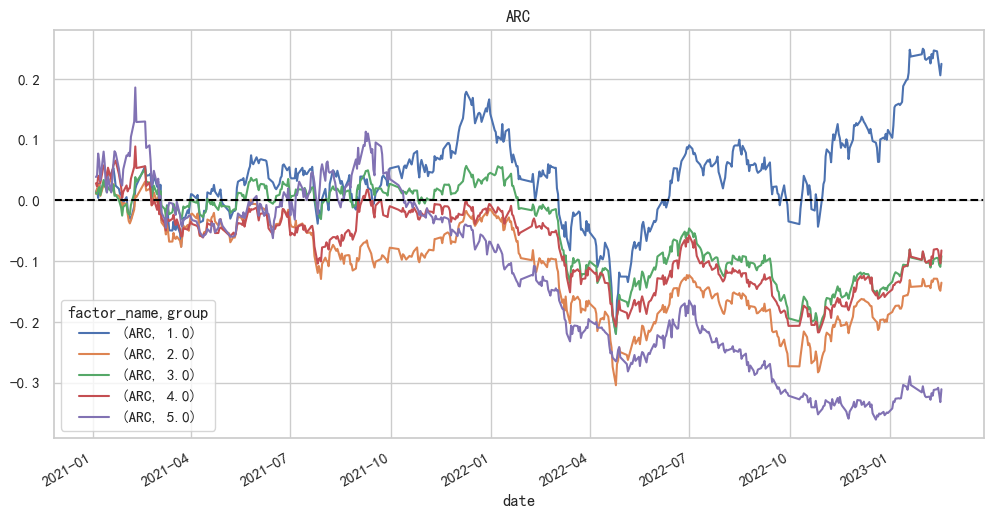

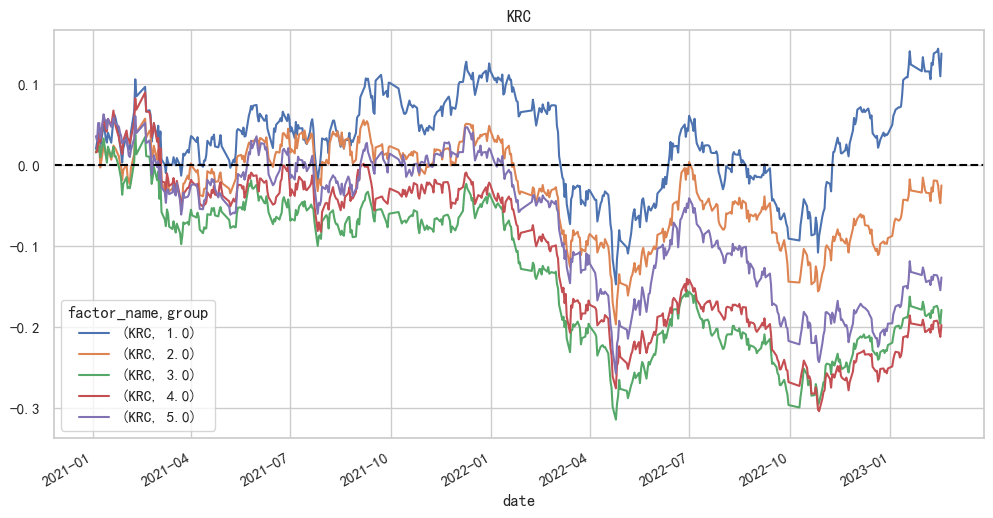

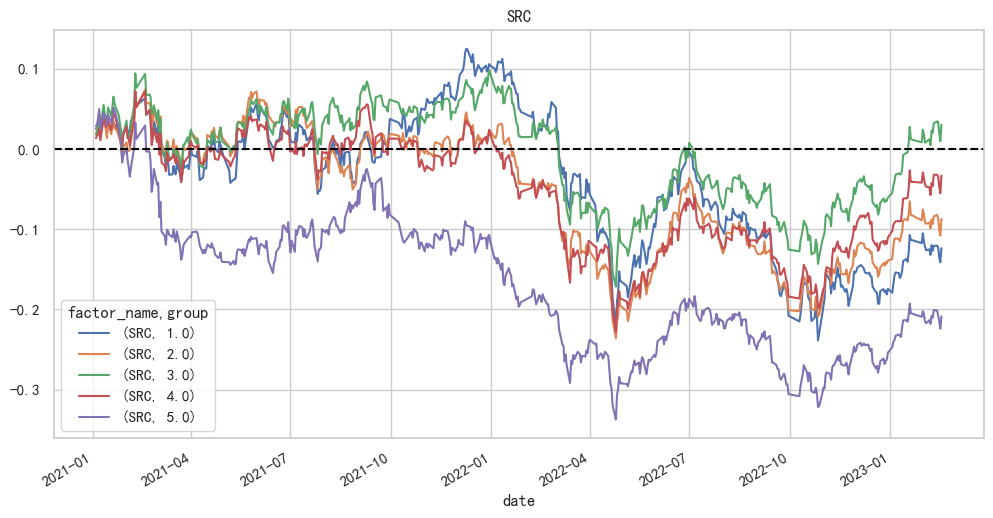

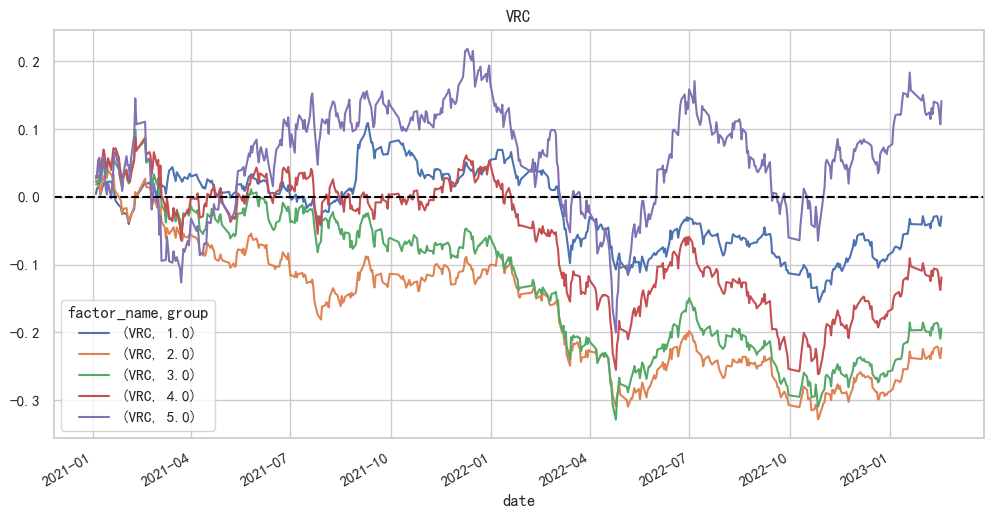

In [7]:
clean_factor: pd.DataFrame = clean_factor_data(df_test)
# 计算分组收益率
group_returns: pd.DataFrame = get_factor_group_returns(
    clean_factor, quantile=5, no_raise=False
)
# 计算累计收益率
group_cum: pd.DataFrame = ep.cum_returns(group_returns)

# 画图
for factor_name, df in group_cum.groupby(level=0, axis=1):
    df.plot(title=factor_name, figsize=(12, 6))
    plt.axhline(0, ls="--", color="black")

## 因子复合

In [8]:
try:
    recorder = record_dict["recorder"]
except NameError:
    # 使用已有模型
    from qlib.workflow import R
    import pickle

    with open("factor_data/turnovercoeff_dataset.pkl", "rb") as f:
        turncoeff_dataset = pickle.load(f)
    # tfs pool 0accc05c53f74dc6827853d7b310307e
    # csi300 34342b9c77c941788eea7b85a27e243e
    # gbdt pool 277db25d948e4423b541d3382044c285
    with R.start():
        recorder = R.get_recorder(
            recorder_name="mlflow_recorder",
            recorder_id="b6fb35b51626493f835c86c7d8a2b1b3",
        )

In [52]:
label_df: pd.DataFrame = turncoeff_dataset.prepare("test", col_set="label")
label_df.columns = ["label"]
pred_df: pd.DataFrame = recorder.load_object("pred.pkl")

# 创建测试集"预测"和“标签”对照表
pred_label_df: pd.DataFrame = pd.concat([pred_df, label_df], axis=1, sort=True).reindex(
    label_df.index
)

## 复合因子表现

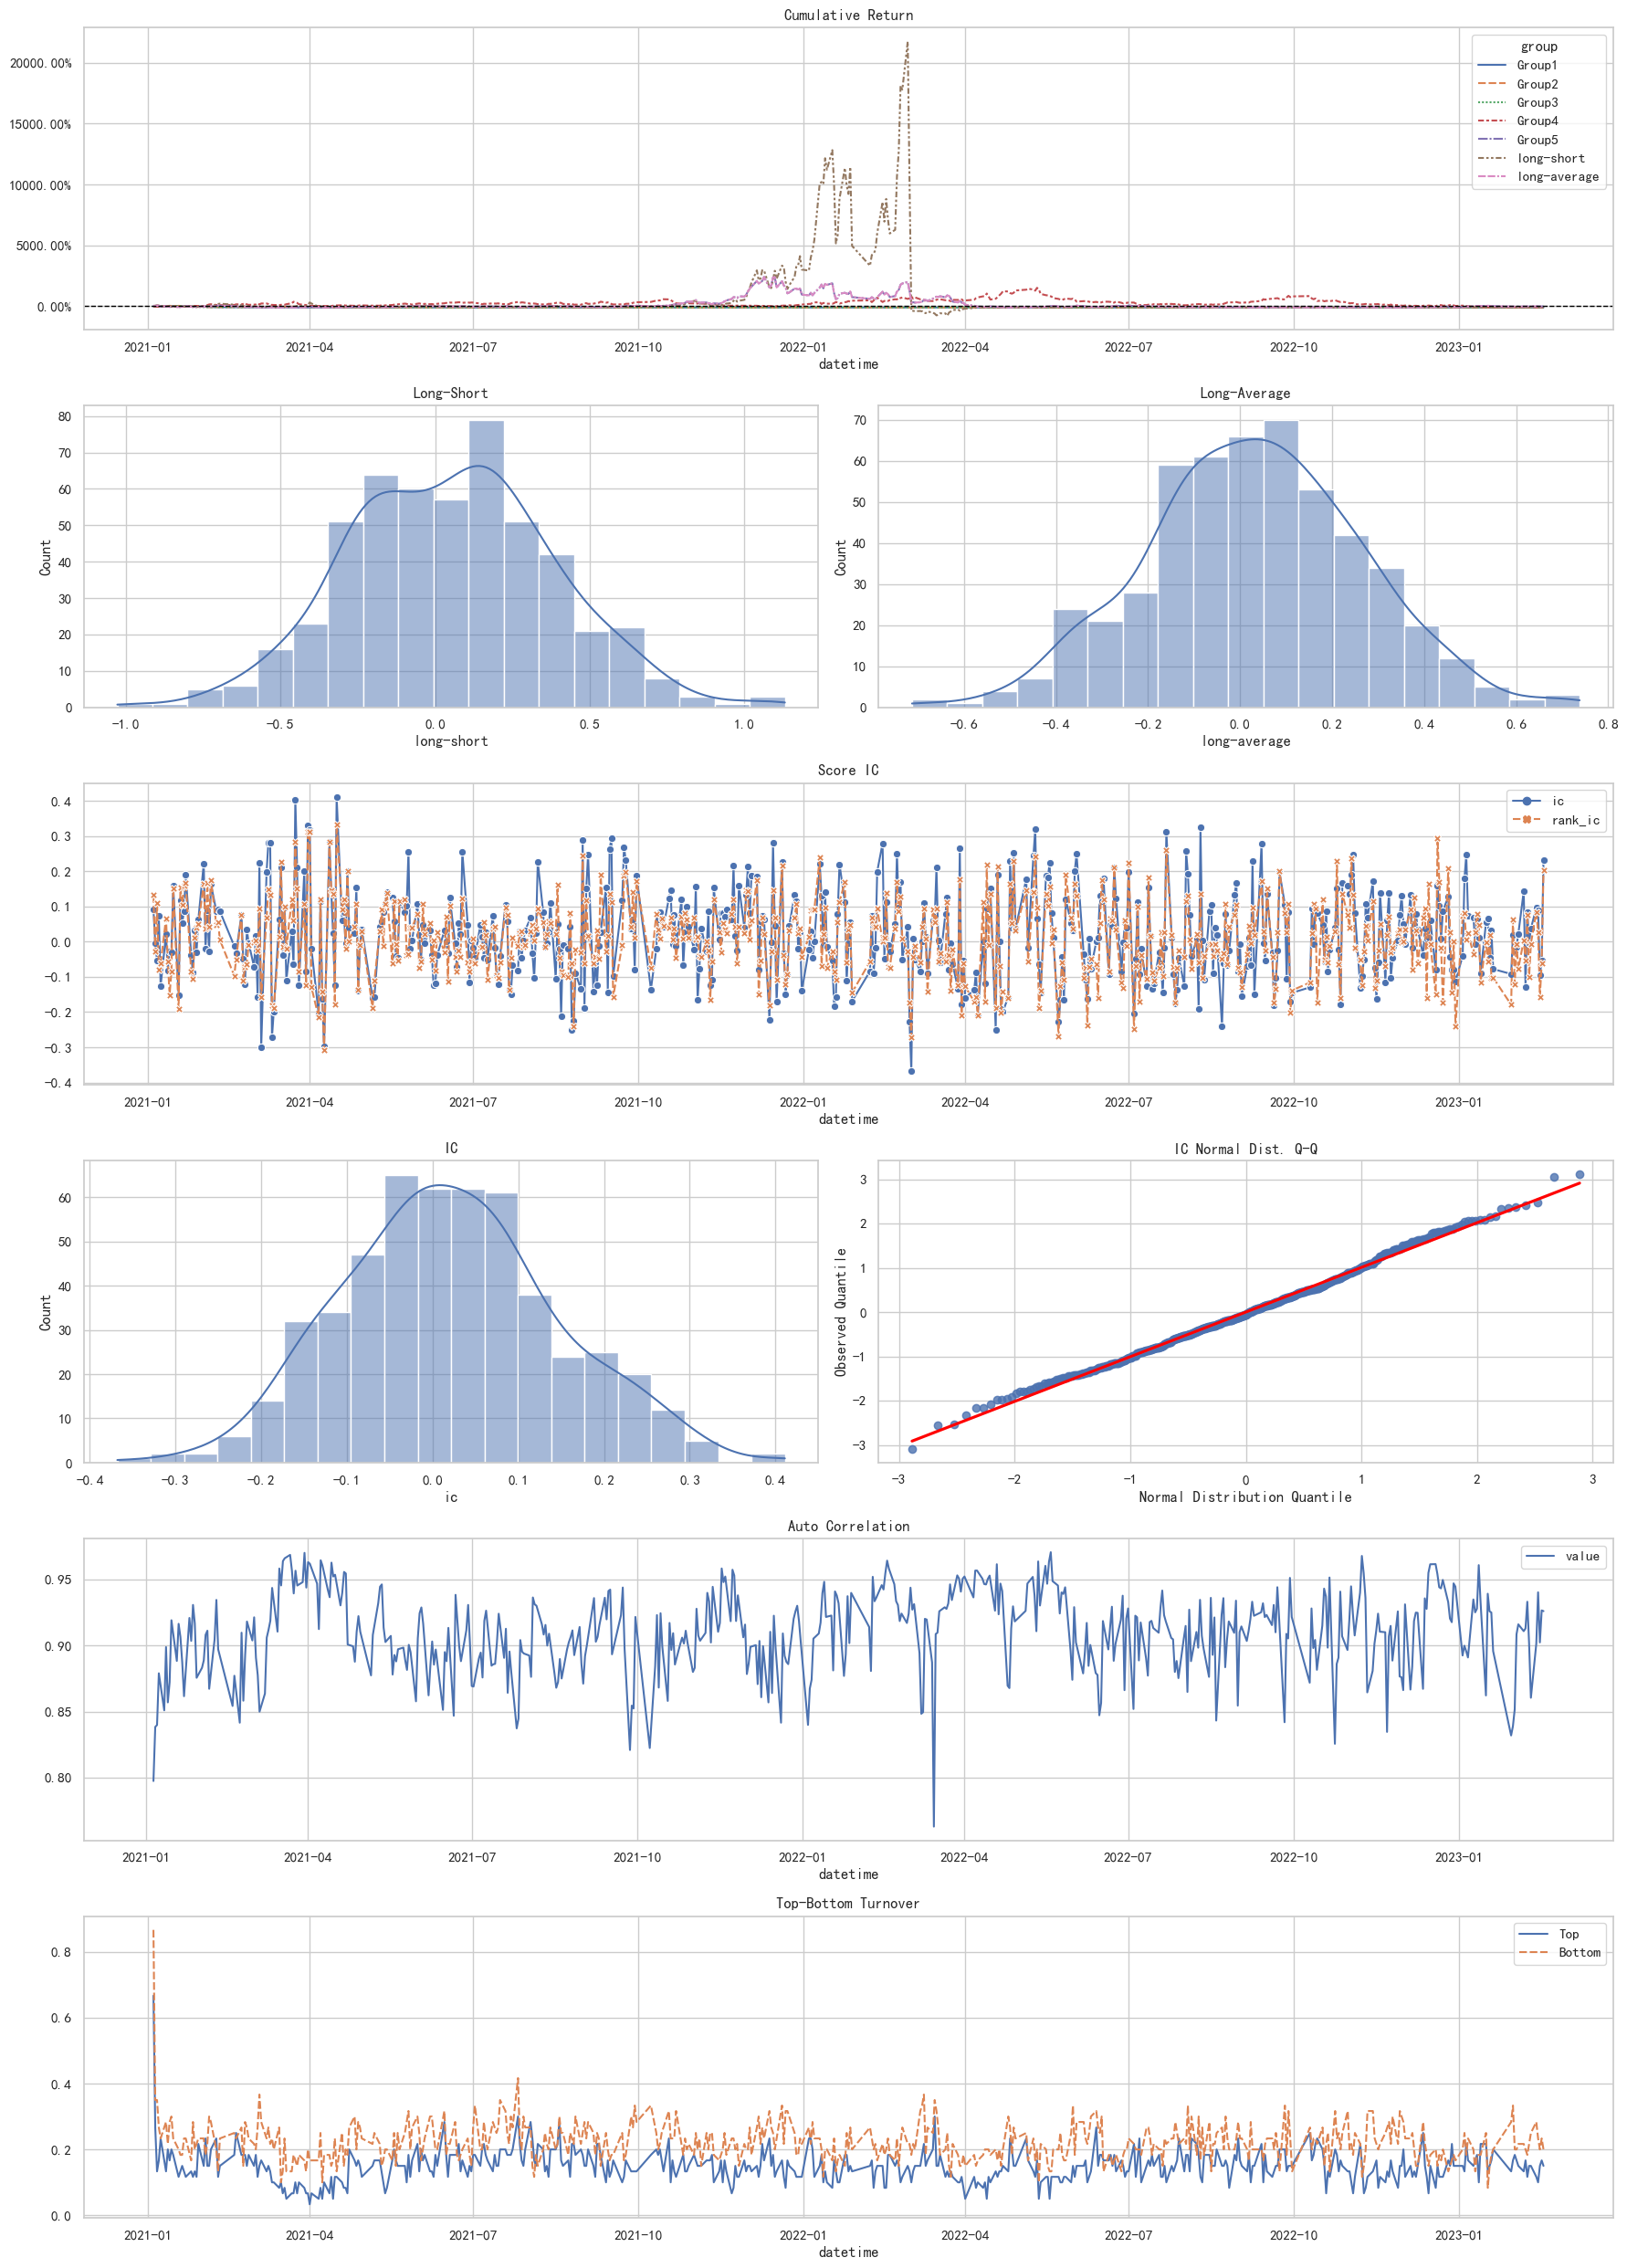

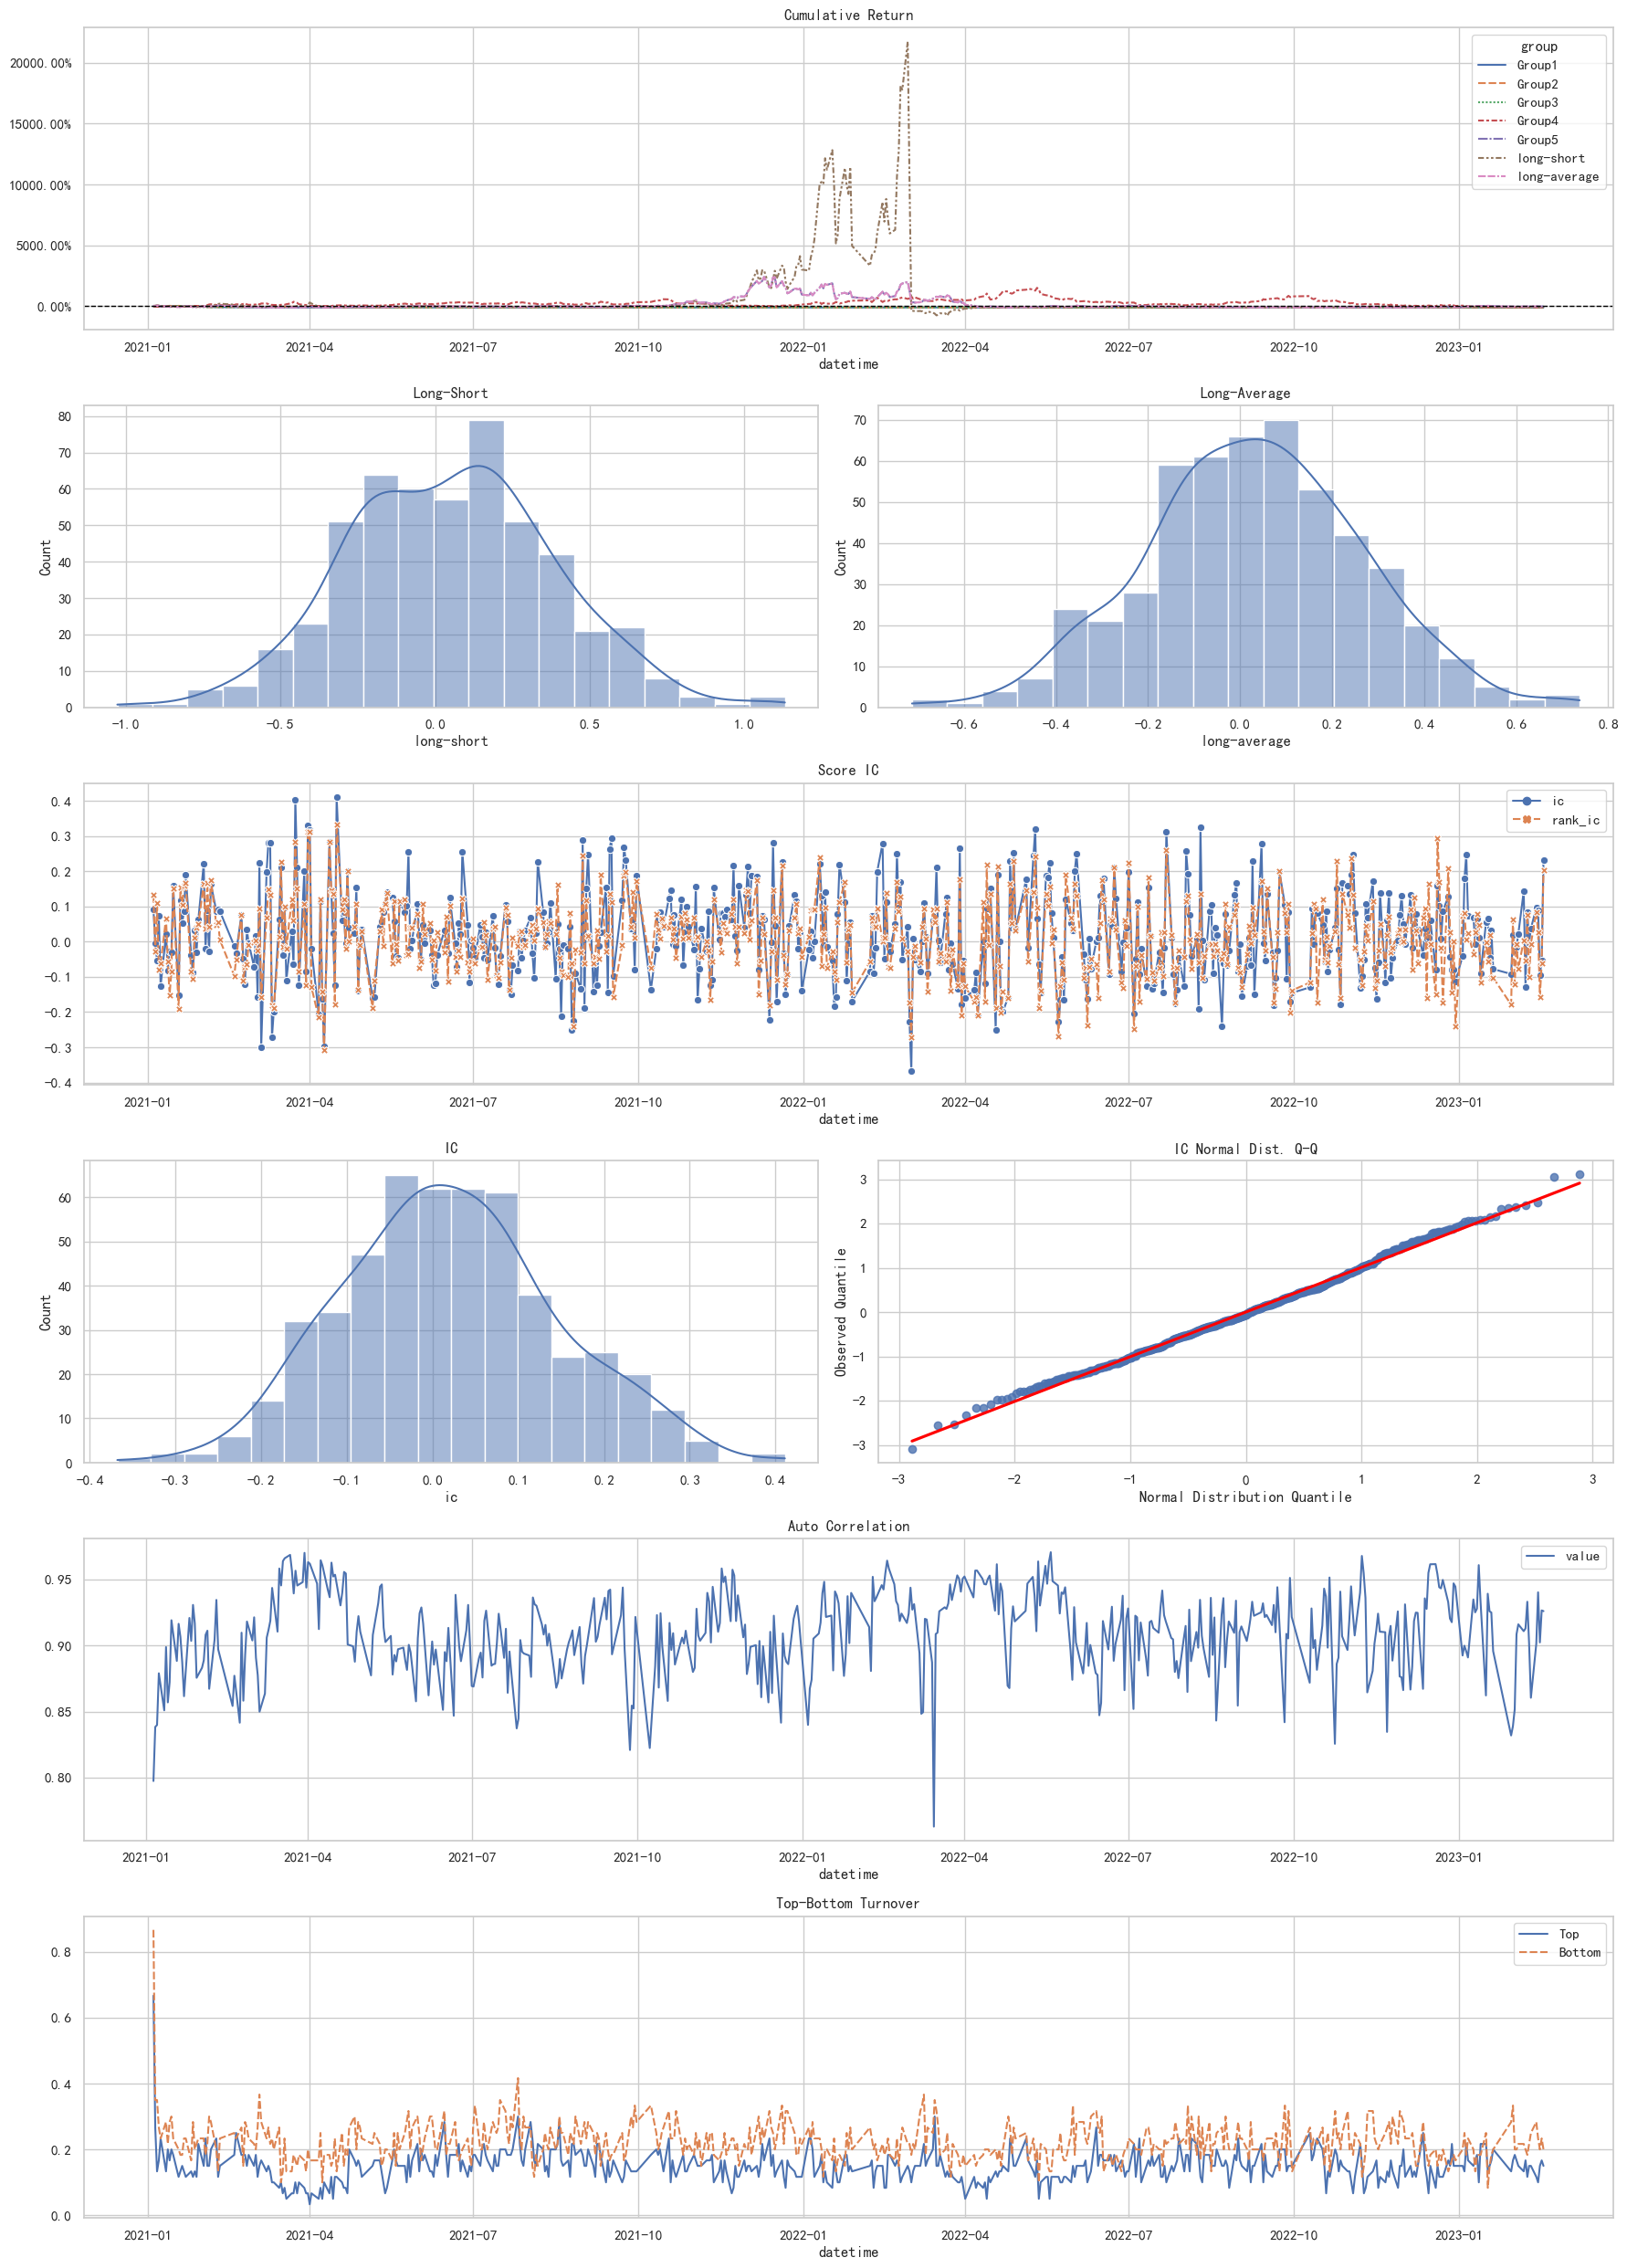

In [53]:
model_performance_graph(pred_label_df, duplicates='drop')

## 回测表现

In [54]:
report_normal_1day_df: pd.DataFrame = recorder.load_object(
    "portfolio_analysis/report_normal_1day.pkl")

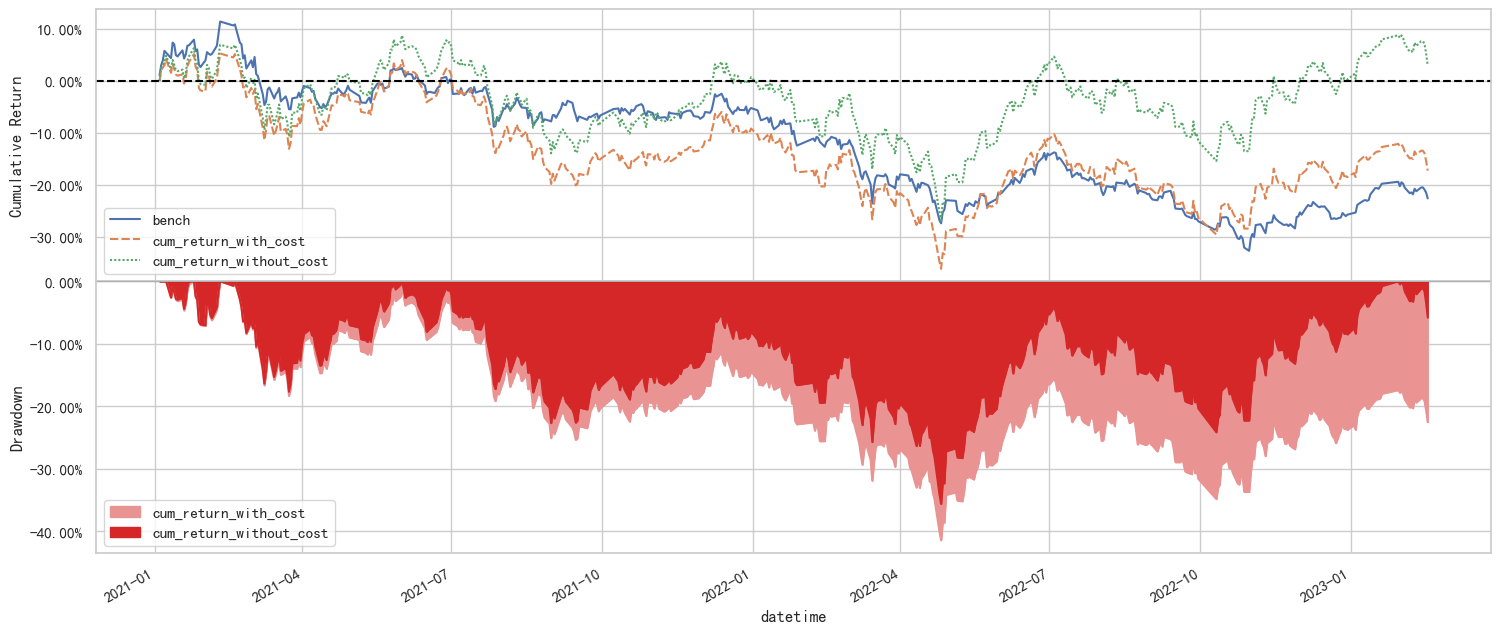

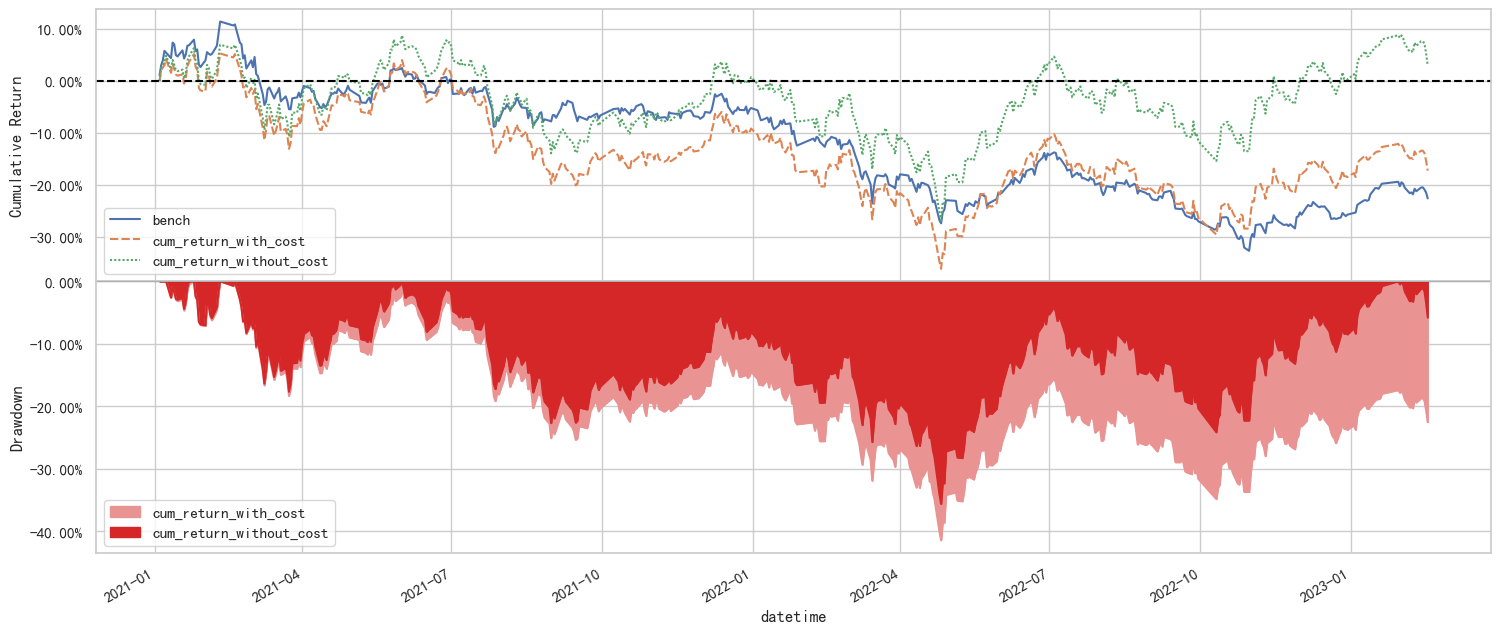

In [55]:
report_graph(report_normal_1day_df)

# 陈浩筹码分布(CYQ)

这个版本的筹码就是我们在通达信，同花顺等行情软件上看到的**筹码因子**

筹码分布来源于中科院陈浩老师于1997年，针对中国市场率先提出的一种技术指标，属于资金面指标。

筹码分布有很多衍生指标，可以分为下面三类，下面介绍如何使用：
1. 形态类，例如："低位密集"个股未来可能会迎来上涨；"高位密集"个股未来会下跌回调；"双峰填谷"代表主力在附近价格吸筹，即将迎来变盘；"低位锁定"代表主力控盘程度高，结合当前上涨力度可以判断是否买入
2. 衍生指标类，例如："活动筹码ASR"刻画当前价位上下区间的筹码比例，该上下区间的筹码往往是短线投资者活动区域，我们可以利用ASR指标来寻找主力控盘强的个股；"成本重心CKDW"同样可以用来判断筹码密集程度，CKDW越大说明高位密集状态越明显，反之说明低位密集状态越明显；"获利盘比例CYQK_C"刻画在当前收盘价对应的获利盘比例，CYQK_C越大说明获利筹码越多，未来上涨阻力越小/上方抛售压力越小；"价格相对位置PRP"用于判断股价高估程度，PRP越大说明无量超涨且主力控盘程度高，反之说明无量超跌且大部分筹码处于套牢状态，是一种危险信号。
3. 实时指标类，同花顺的DDE等大单/主力指标，这里不做深入研究

## 筹码分布计算原理

筹码分布理论就是根据股票交易筹码流动的特点，对大盘或个股的历史成交情况进行分析，得出其筹码分布，然后根据这个筹码分布图来预测以后的走势。筹码分析理论的自然规律基础，是筹码流动的特点。
股票交易都是通过买卖双方在某个价位进行买卖成交而实现的。随着股票的上涨或下跌，在不同的价格区域产生着不同的成交量，这些成交量在不同的价位的分布量，形成了股票不同价位的持仓成本。
**筹码分布主要应用于筹码持仓成本分析**。一轮行情发展都是由成本转换开始的，又因成本转换而结束。什么是成本转换呢？形象的说，成本转换就是筹码搬家，是指持仓筹码由一个价位向另一个价位搬运的过程，它不仅仅是股价的转换，更重要的是持仓筹码数量的转换。股票的走势在表象上体现了股价的变化，而其内在的本质却体现了持仓成本的转换。

2008年之前交易所公布topview数据,每天机构/散户/主力的买入量；之后被交易所叫停，我们只能粗略估算各个价位对应的持仓量，具体方法如下：
使用日间数据，假设成交量服从某种特定分布，按特定时间衰减，进行换手累加得到估计值。

## 筹码分布估计算法:

已知当天low/high/vol,假设这一天内的各个价位的建仓价格符合三角分布,即可求得当天新建仓位的筹码分布,按换手率衰减比例进行累计最终可求：

$$curpdf=triang(low,high,vol) \tag{1}$$
$$decat = turnover\_rate * Coeff \tag{2}$$
$$cumpdf=\begin{cases}i=0, decay * curpdf \\
i > 0,cumpdf * (1-decay)+decay*curpdf\end{cases} \tag{3}$$

其中Coeff(历史换手衰减系数)默认为1，它是一个常数参数，我们用来赋予今天换手率，也既是当日被移动的成本的权重。如果今天的换手率是A，衰减系数是n，那么我们计算昨日的被移动的筹码的总量是A*n,如果n取值为1，就是一般意义上理解的今天换手多少，就有多少筹码被从作日的成本分布中被搬移；如果n是2，那么我们就放大了作日被移动的筹码的总量..这样的目的在于突出“离现在越近的筹码分布其含义越明显”。

**基本的一些概念**
- 平均分布：将当日的换手筹码在当日的最高价和最低价之间平均分布。
- 三角形分布：将当日的换手筹码在当日的最高价、最低价和平均价之间三角形分布。

## 筹码分布可视化

In [3]:
# 数据获取
pool: List = D.list_instruments(D.instruments("csi300"), as_list=True)
print(pool[0])
frame: pd.DataFrame = D.features(
    [pool[0]],
    fields=["$close", "$high", "$low", "$vol", "$turnover_rate"],
)
frame.reset_index(level=0, inplace=True, drop=True)
frame.columns = frame.columns.str.replace("$", "", regex=True)

slice_frame: pd.DataFrame = frame.iloc[-80:].copy()

002202.SZ


## 三角分布

<AxesSubplot: title={'center': '002202.SZ-三角分布'}, xlabel='price', ylabel='volume'>

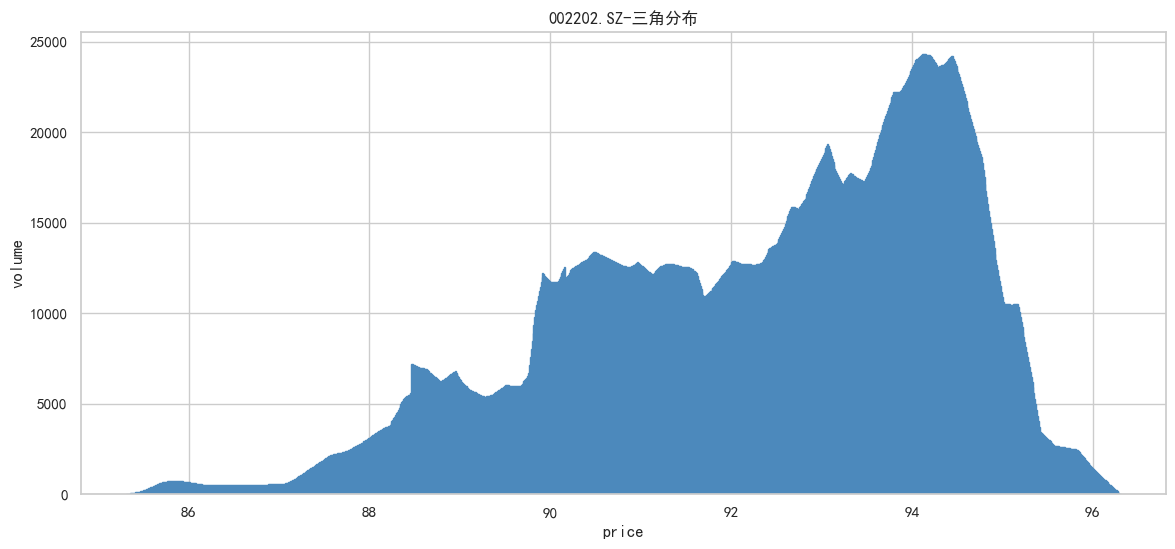

In [4]:
plot_dist_chips(slice_frame, "triang", "002202.SZ-三角分布")

## 平均分布

<AxesSubplot: title={'center': '002202.SZ-平均分布'}, xlabel='price', ylabel='volume'>

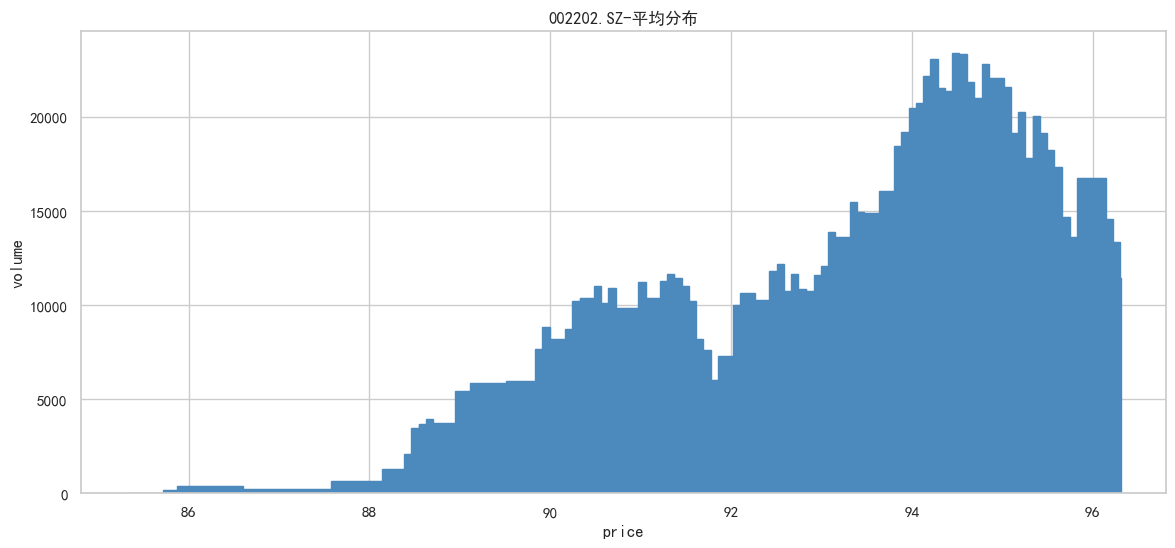

In [5]:
plot_dist_chips(slice_frame, "uniform", "002202.SZ-平均分布")

## 换手率半衰期

<AxesSubplot: title={'center': '002202.SZ-换手率衰减'}, xlabel='price', ylabel='volume'>

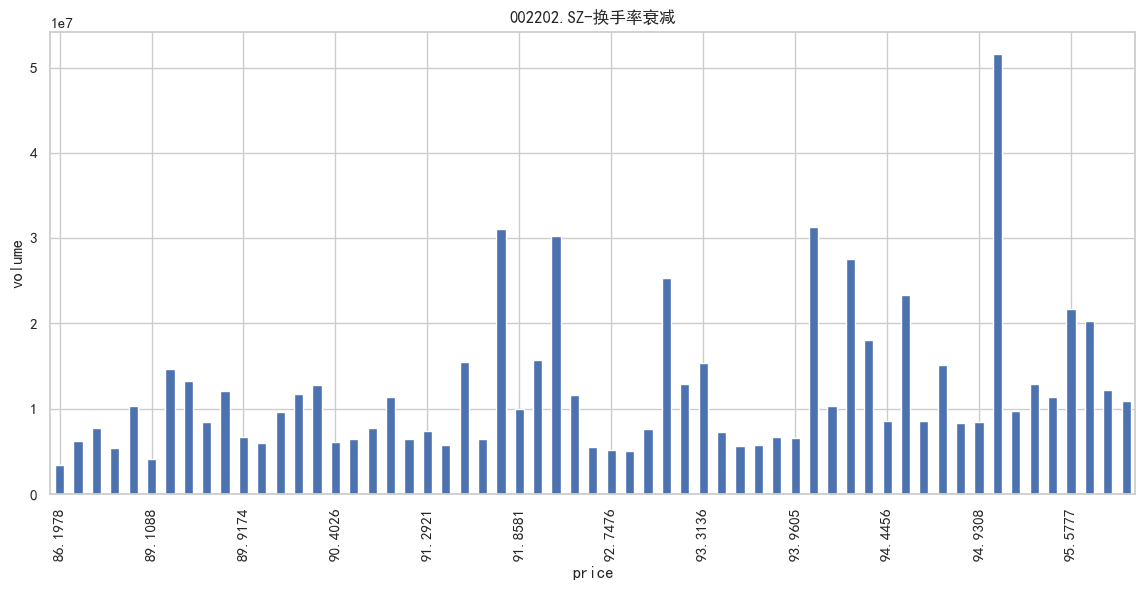

In [6]:
plot_dist_chips(slice_frame, "turn_coeff", "002202.SZ-换手率衰减")

## 因子构建

In [19]:
###################################
# 参数配置
###################################
# 数据处理器参数配置：整体数据开始结束时间，训练集开始结束时间，股票池
TARIN_PERIODS: Tuple = ("2014-01-01", "2017-12-31")
VALID_PERIODS: Tuple = ("2018-01-01", "2019-12-31")
TEST_PERIODS: Tuple = ("2020-01-01", "2023-02-17")


dataset_config: Dict = get_tsdataset_config(
    "csi300",
    TARIN_PERIODS,
    VALID_PERIODS,
    TEST_PERIODS,
    20,
    "Chips",
)


if Path("factor_data/chip_ts_dataset.pkl").exists():
    import pickle

    with open("factor_data/chip_ts_dataset.pkl", "rb") as f:
        cyq_ts_dataset = pickle.load(f)
else:
    cyq_ts_dataset = init_instance_by_config(dataset_config)  # 类型DatasetH

    # 保存数据方便后续使用
    cyq_ts_dataset.config(dump_all=True, recursive=True)
    cyq_ts_dataset.to_pickle(path="cyq_ts_dataset.pkl", dump_all=True)

cyq_record: Dict = run_model(
    cyq_ts_dataset,
    "transformer_ts",
    start_time=TEST_PERIODS[0],
    end_time=TEST_PERIODS[1],
    model_kw={"d_feat": 12,"num_layers":8, "seed": 42,'n_jobs':20},
    experiment_name="cyq",
    trained_model="trained_model.pkl",
)

[77228:MainThread](2023-04-09 18:43:11,650) INFO - qlib.TransformerModel - [pytorch_transformer_ts.py:62] - Naive Transformer:
batch_size : 8192
device : cuda:0


[18:43:11] 实验名:cyq,训练模型:trained_model.pkl,开始运行...                                   ]8;id=52050;file://d:\WorkSpace\visualization_stock_market\sqlalchemy_to_data\测试相关\筹码分布算法\scr\qlib_workflow.py\qlib_workflow.py]8;;\:]8;id=186347;file://d:\WorkSpace\visualization_stock_market\sqlalchemy_to_data\测试相关\筹码分布算法\scr\qlib_workflow.py#303\303]8;;\

[77228:MainThread](2023-04-09 18:43:11,674) INFO - qlib.workflow - [exp.py:258] - Experiment 5 starts running ...
[77228:MainThread](2023-04-09 18:43:11,695) INFO - qlib.workflow - [recorder.py:341] - Recorder e8e62a5185394314b5a7d79a17160059 starts running under Experiment 5 ...
[77228:MainThread](2023-04-09 18:43:12,771) INFO - qlib.TransformerModel - [pytorch_transformer_ts.py:175] - training...
[77228:MainThread](2023-04-09 18:43:12,772) INFO - qlib.TransformerModel - [pytorch_transformer_ts.py:179] - Epoch0:
[77228:MainThread](2023-04-09 18:43:12,773) INFO - qlib.TransformerModel - [pytorch_transformer_ts.py:180] - training...
[77228:MainThread](2023-04-09 18:48:43,938) INFO - qlib.TransformerModel - [pytorch_transformer_ts.py:182] - evaluating...
[77228:MainThread](2023-04-09 18:59:20,864) INFO - qlib.TransformerModel - [pytorch_transformer_ts.py:185] - train -0.948011, valid -0.974081
[77228:MainThread](2023-04-09 18:59:20,874) INFO - qlib.TransformerModel - [pytorch_transformer

'The following are prediction results of the TransformerModel model.'
                          score
datetime   instrument          
2020-01-02 000001.SZ   0.009306
2020-01-03 000001.SZ  -0.003729
2020-01-06 000001.SZ   0.000270
2020-01-07 000001.SZ   0.001836
2020-01-08 000001.SZ   0.015594
{'IC': 0.009371963073639761,
 'ICIR': 0.07478838851389212,
 'Rank IC': 0.009187091166787224,
 'Rank ICIR': 0.07208683351672622}


[77228:MainThread](2023-04-09 22:02:08,980) INFO - qlib.backtest caller - [__init__.py:93] - Create new exchange
[77228:MainThread](2023-04-09 22:03:36,887) WARNING - qlib.online operator - [exchange.py:219] - $open field data contains nan.
[77228:MainThread](2023-04-09 22:03:36,890) WARNING - qlib.online operator - [exchange.py:219] - $open field data contains nan.
[77228:MainThread](2023-04-09 22:08:43,535) WARNING - qlib.BaseExecutor - [executor.py:121] - `common_infra` is not set for <qlib.backtest.executor.SimulatorExecutor object at 0x000002453DCE6D90>


...

d:\anaconda3\envs\qlib_env\lib\site-packages\qlib\utils\index_data.py:482: RuntimeWarning: Mean of empty slice
  return np.nanmean(self.data)
[77228:MainThread](2023-04-09 22:09:07,409) INFO - qlib.workflow - [record_temp.py:505] - Portfolio analysis record 'port_analysis_1day.pkl' has been saved as the artifact of the Experiment 5


'The following are analysis results of benchmark return(1day).'
                       risk
mean               0.000063
std                0.012879
annualized_return  0.014996
information_ratio  0.075474
max_drawdown      -0.473379
'The following are analysis results of the excess return without cost(1day).'
                       risk
mean               0.000464
std                0.006855
annualized_return  0.110492
information_ratio  1.044789
max_drawdown      -0.182821
'The following are analysis results of the excess return with cost(1day).'
                       risk
mean               0.000054
std                0.006854
annualized_return  0.012763
information_ratio  0.120703
max_drawdown      -0.281252


[77228:MainThread](2023-04-09 22:09:07,427) INFO - qlib.workflow - [record_temp.py:530] - Indicator analysis record 'indicator_analysis_1day.pkl' has been saved as the artifact of the Experiment 5


'The following are analysis results of indicators(1day).'
     value
ffr    1.0
pa     0.0
pos    0.0
info {'class': 'Recorder', 'id': 'e8e62a5185394314b5a7d79a17160059', 'name': 'mlflow_recorder', 'experiment_id': '5', 'start_time': '2023-04-09 18:43:11', 'end_time': None, 'status': 'RUNNING'}


[77228:MainThread](2023-04-09 22:09:07,442) INFO - qlib.timer - [log.py:128] - Time cost: 0.006s | waiting `async_log` Done


## 单因子分布

In [ ]:
# TSDatasetH生成数据并非pd.DataFrame
# 可以使用DatasetH或者QlibData来生成因子数据 因子生成差不多需要200~300min
try:
    cyq_dataset.prepare(segments="test", data_key="raw")
except NameError:
    import pickle

    if Path("factor_data/chip_dataset.pkl").exists():
        with open("factor_data/chip_dataset.pkl", "rb") as f:
            cyq_dataset = pickle.load(f)

    else:
        dataset_config: Dict = get_dataset_config(
            "csi300",
            TARIN_PERIODS,
            VALID_PERIODS,
            TEST_PERIODS,
            "Chips",
        )
        cyq_dataset = init_instance_by_config(dataset_config)  # 类型DatasetH

        # 保存数据方便后续使用
        cyq_dataset.config(dump_all=True, recursive=True)
        cyq_dataset.to_pickle(path="cyq_dataset.pkl", dump_all=True)

df_test: pd.DataFrame = cyq_dataset.prepare(segments="test", data_key="raw")
df_test.rename(columns={"LABEL0": "next_ret"}, inplace=True)

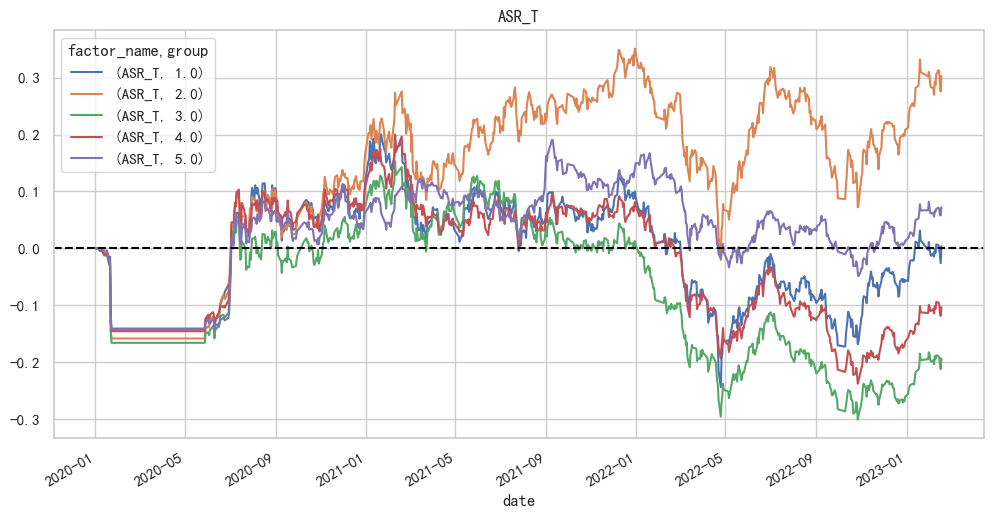

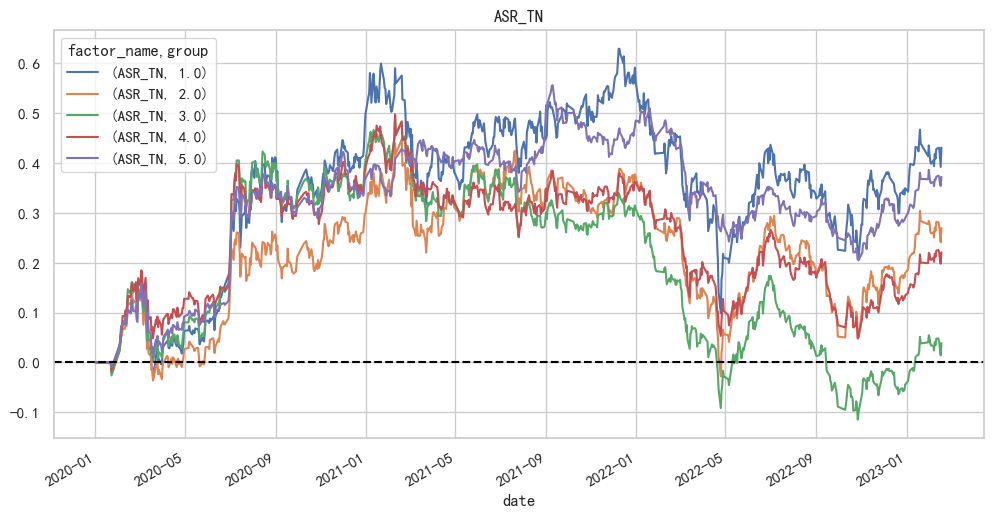

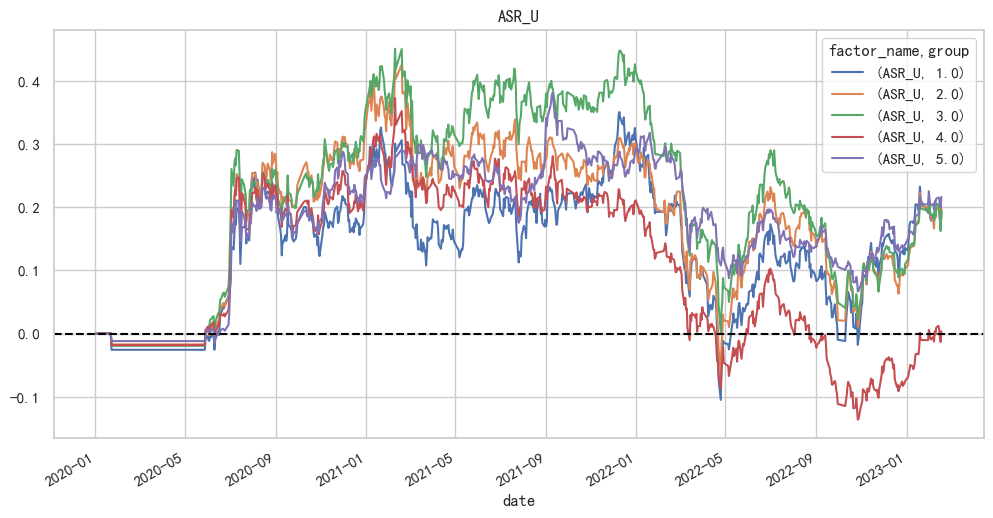

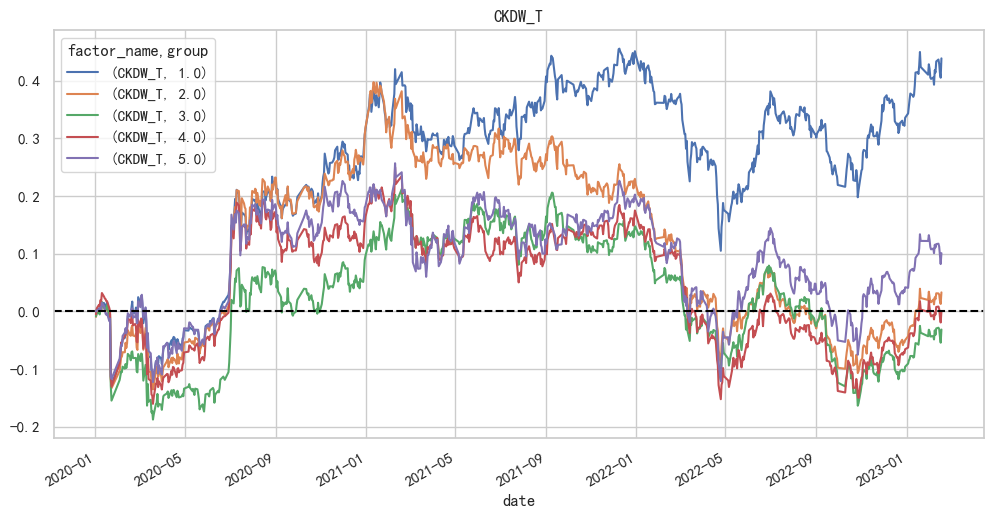

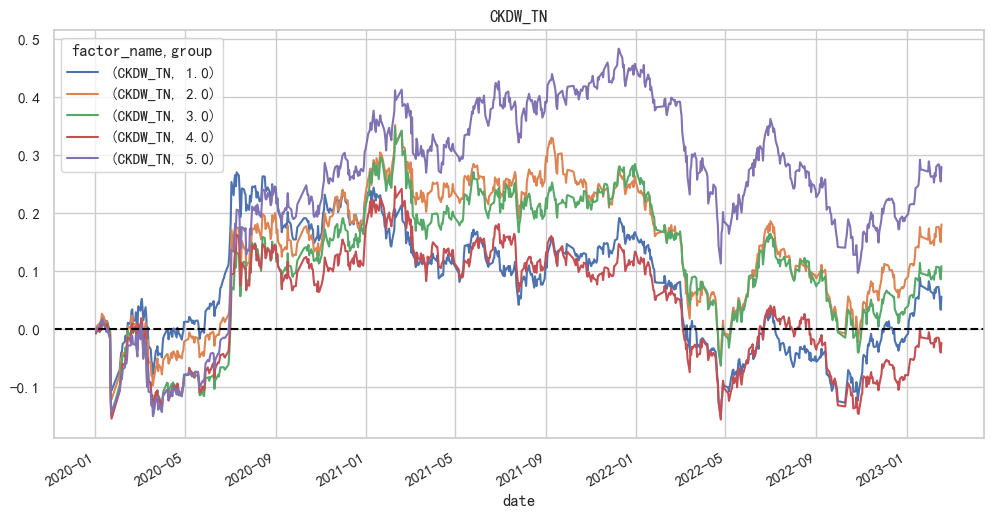

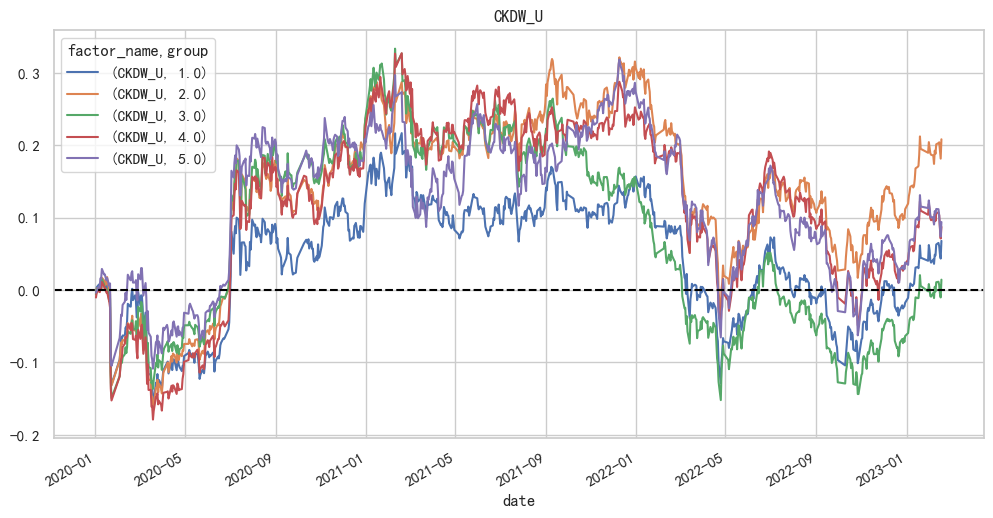

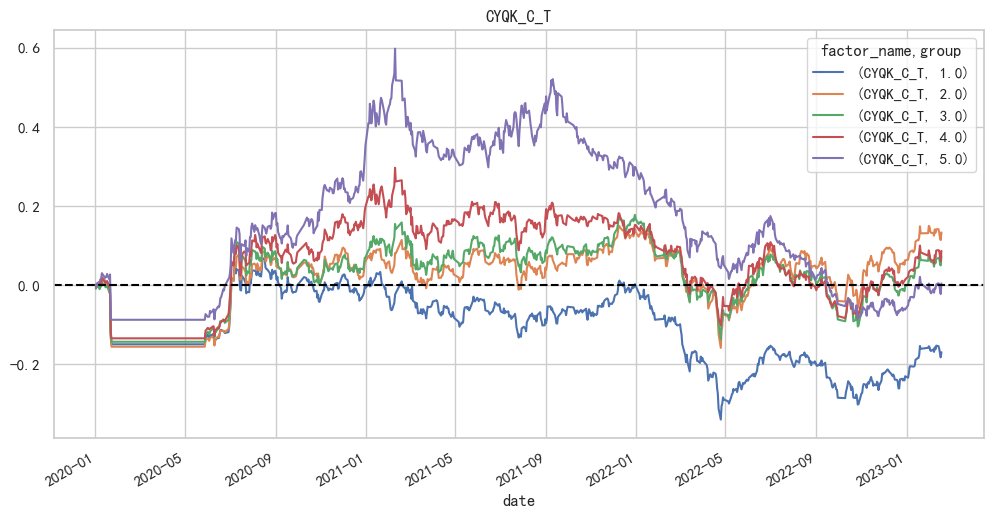

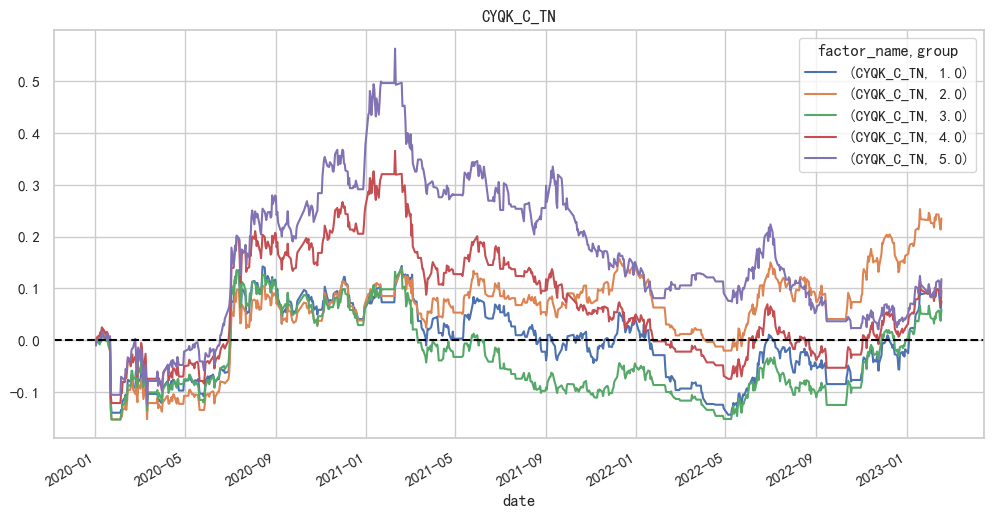

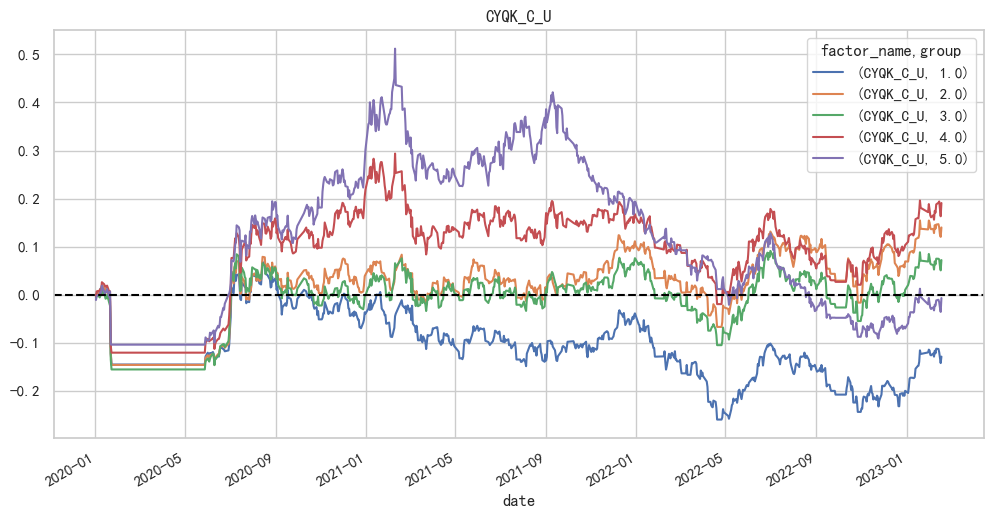

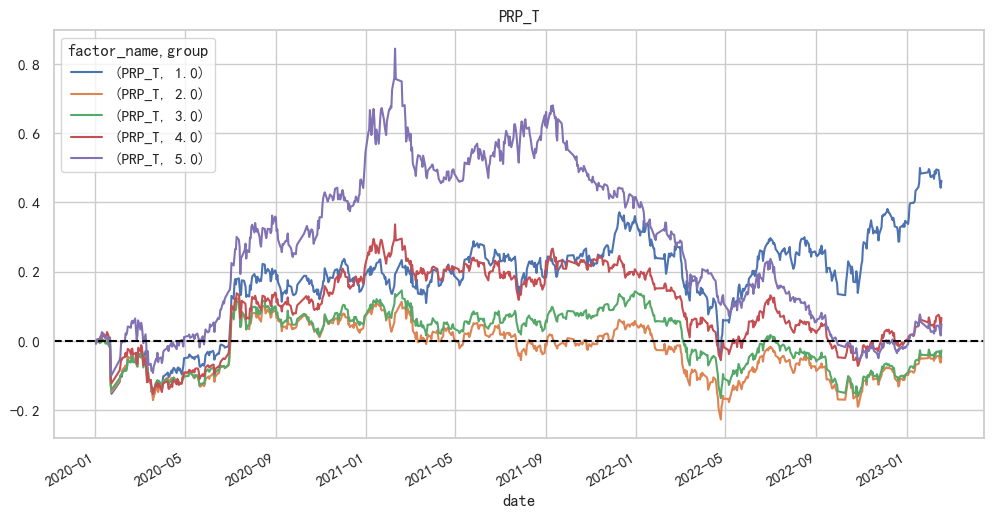

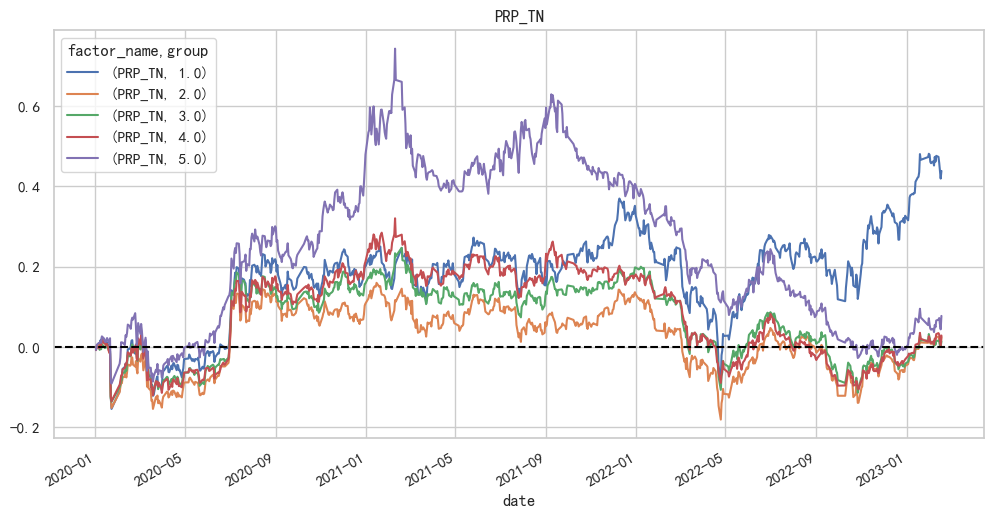

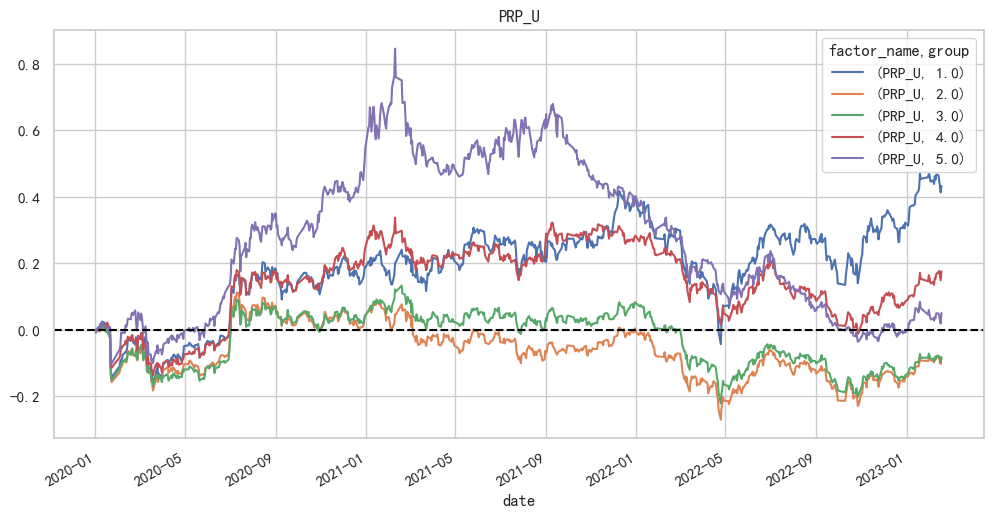

In [12]:
clean_factor: pd.DataFrame = clean_factor_data(df_test)
# 计算分组收益率
group_returns: pd.DataFrame = get_factor_group_returns(
    clean_factor, quantile=5, no_raise=True
)
# 计算累计收益率
group_cum: pd.DataFrame = ep.cum_returns(group_returns)

# 画图
for factor_name, df in group_cum.groupby(level=0, axis=1):
    df.plot(title=factor_name, figsize=(12, 6))
    plt.axhline(0, ls="--", color="black")

## 复合因子

In [20]:
try:
    recorder = record_dict["recorder"]
except NameError:
    # 使用已有模型
    from qlib.workflow import R
    import pickle

    with open("factor_data/chip_dataset.pkl", "rb") as f:
        cyq_dataset = pickle.load(f)
    # tcn layer 8:5a8fbb3d07ca4bcf8883589dcebad44d
    # transform layer 2:e7539ce11aad4c8c92c3e2be518b9106
    # transform layer 8 :e8e62a5185394314b5a7d79a17160059
    with R.start():
        recorder = R.get_recorder(
            recorder_name="mlflow_recorder",
            recorder_id="5a8fbb3d07ca4bcf8883589dcebad44d",
        )

[77228:MainThread](2023-04-09 22:11:26,486) INFO - qlib.workflow - [exp.py:258] - Experiment 2 starts running ...
[77228:MainThread](2023-04-09 22:11:26,511) INFO - qlib.workflow - [recorder.py:341] - Recorder 18e1bb1381904a5e9d1bc350d8f6e5c4 starts running under Experiment 2 ...
[77228:MainThread](2023-04-09 22:11:27,000) INFO - qlib.timer - [log.py:128] - Time cost: 0.001s | waiting `async_log` Done


In [21]:
label_df = recorder.load_object("label.pkl")
label_df.columns = ["label"]
pred_df: pd.DataFrame = recorder.load_object("pred.pkl")

# 创建测试集"预测"和“标签”对照表
pred_label_df: pd.DataFrame = pd.concat([pred_df, label_df], axis=1, sort=True).reindex(
    label_df.index
)

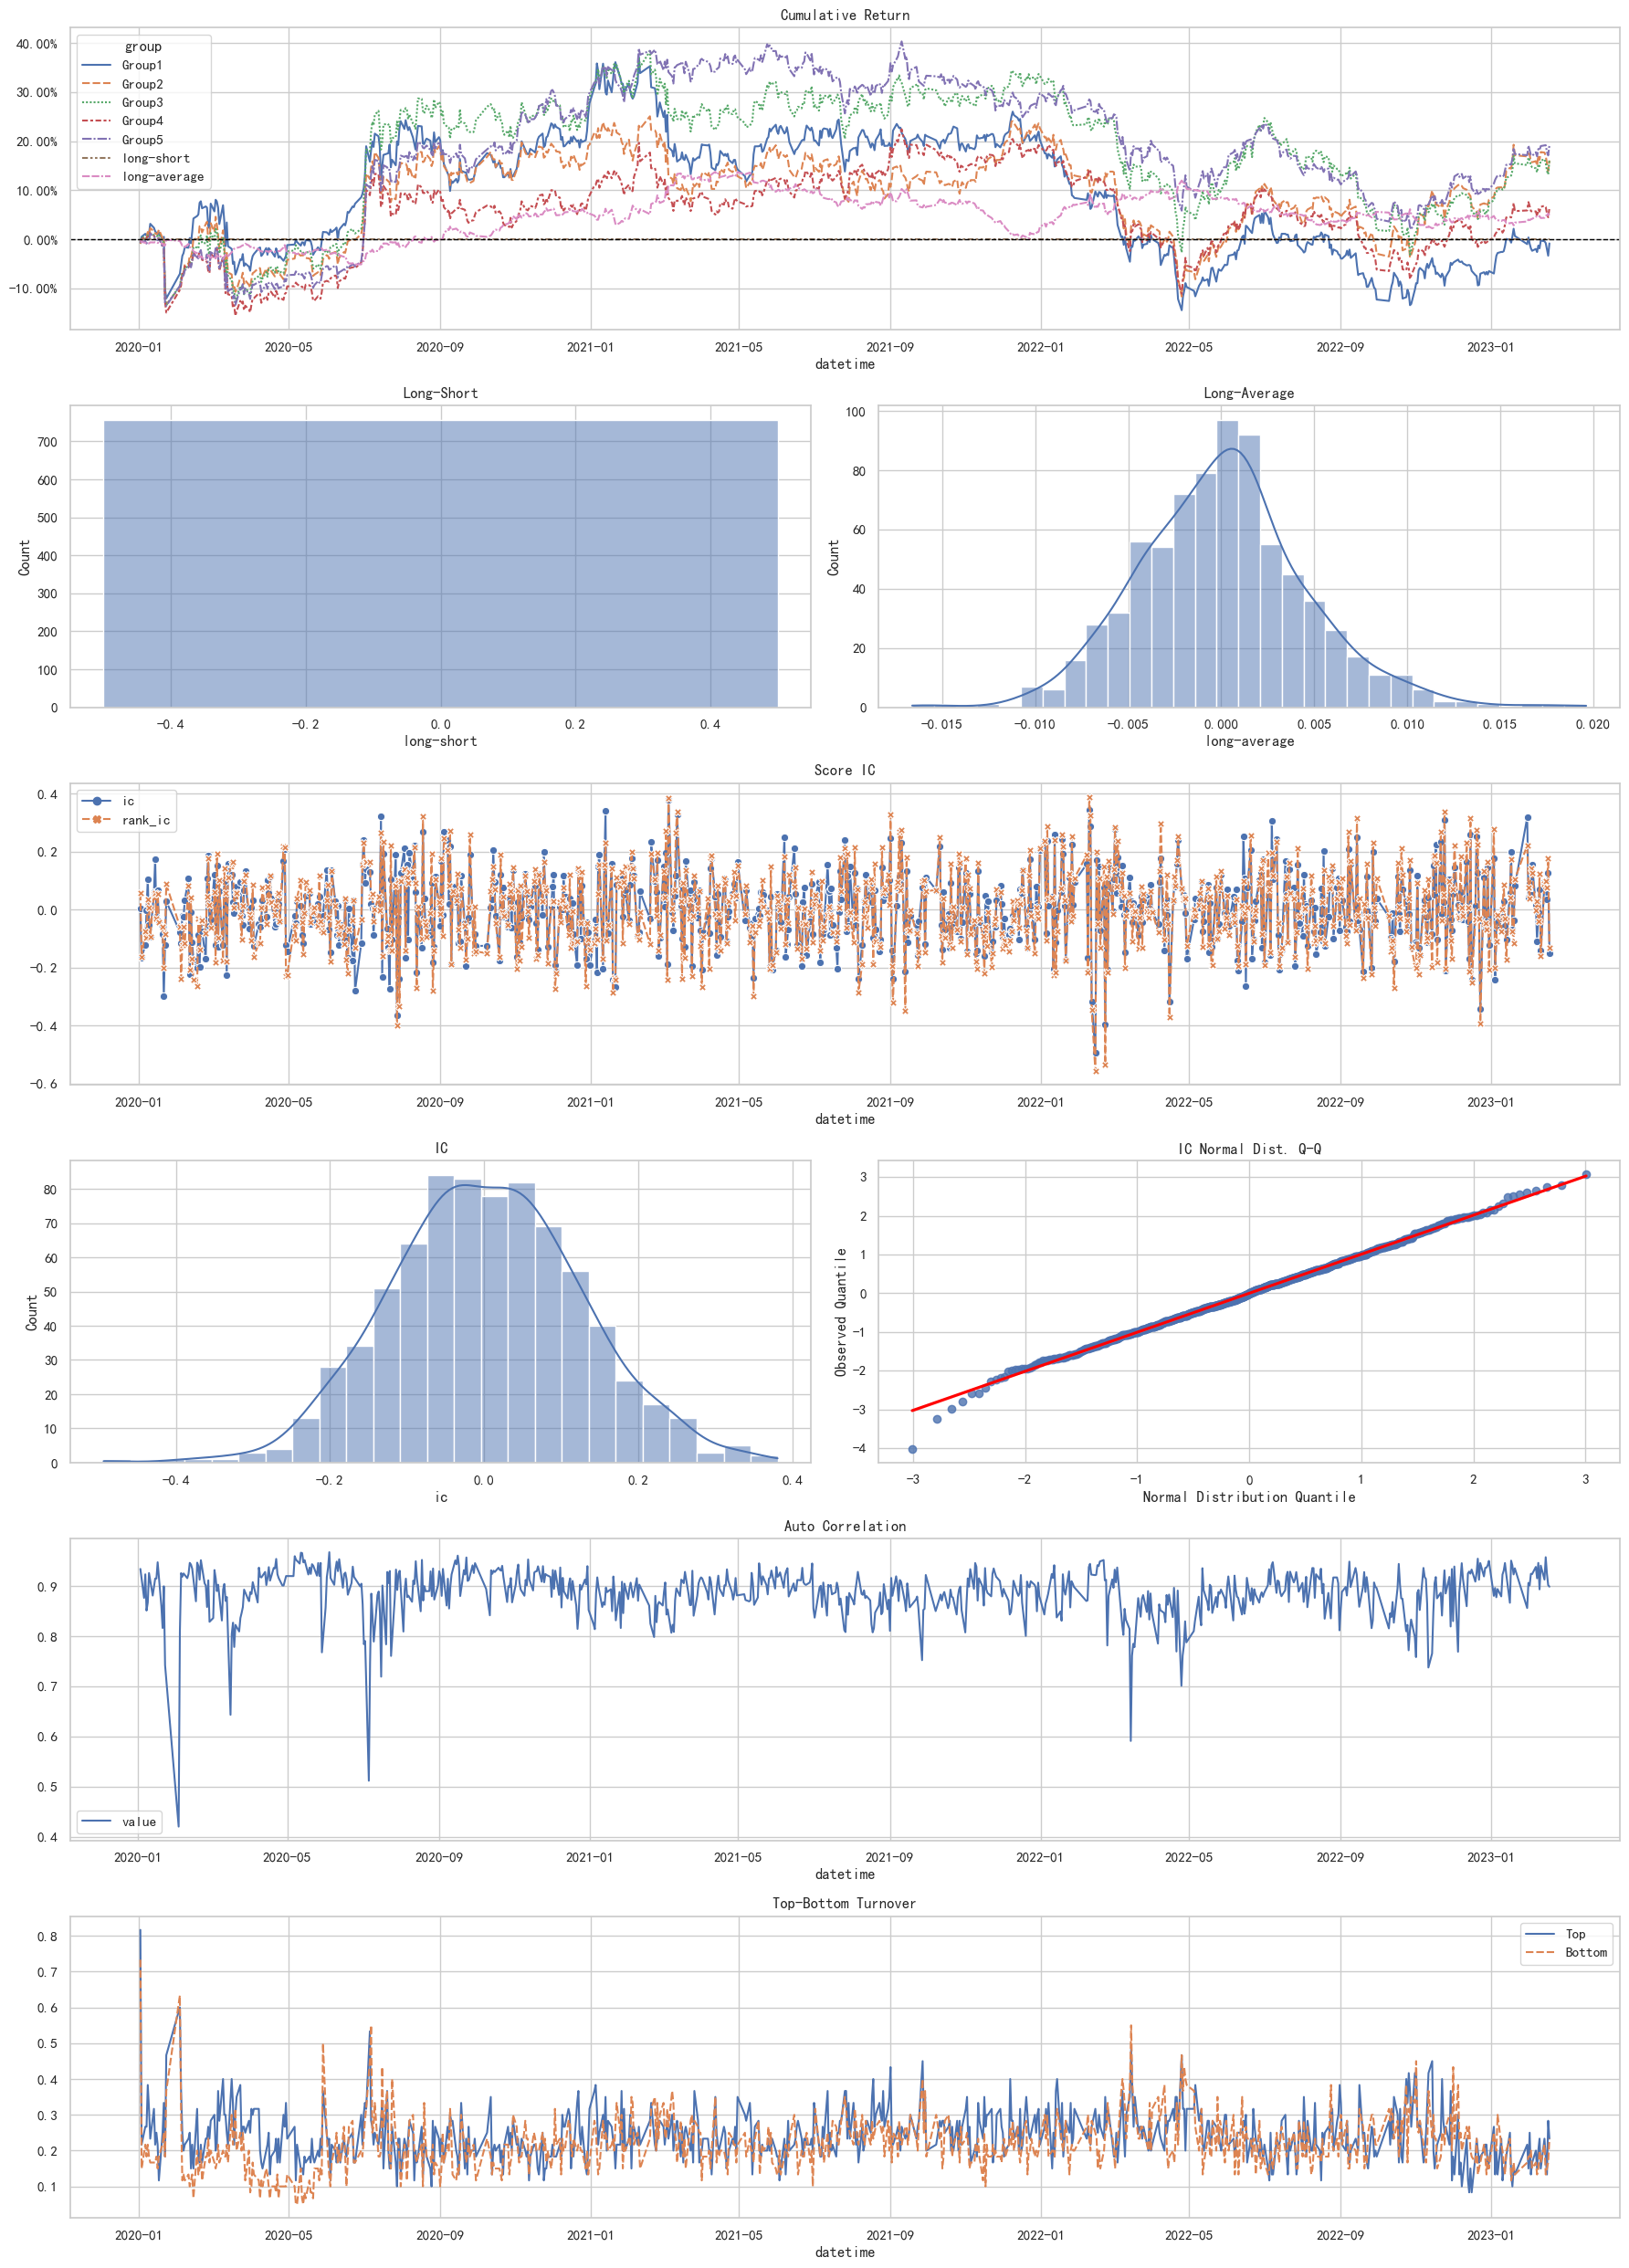

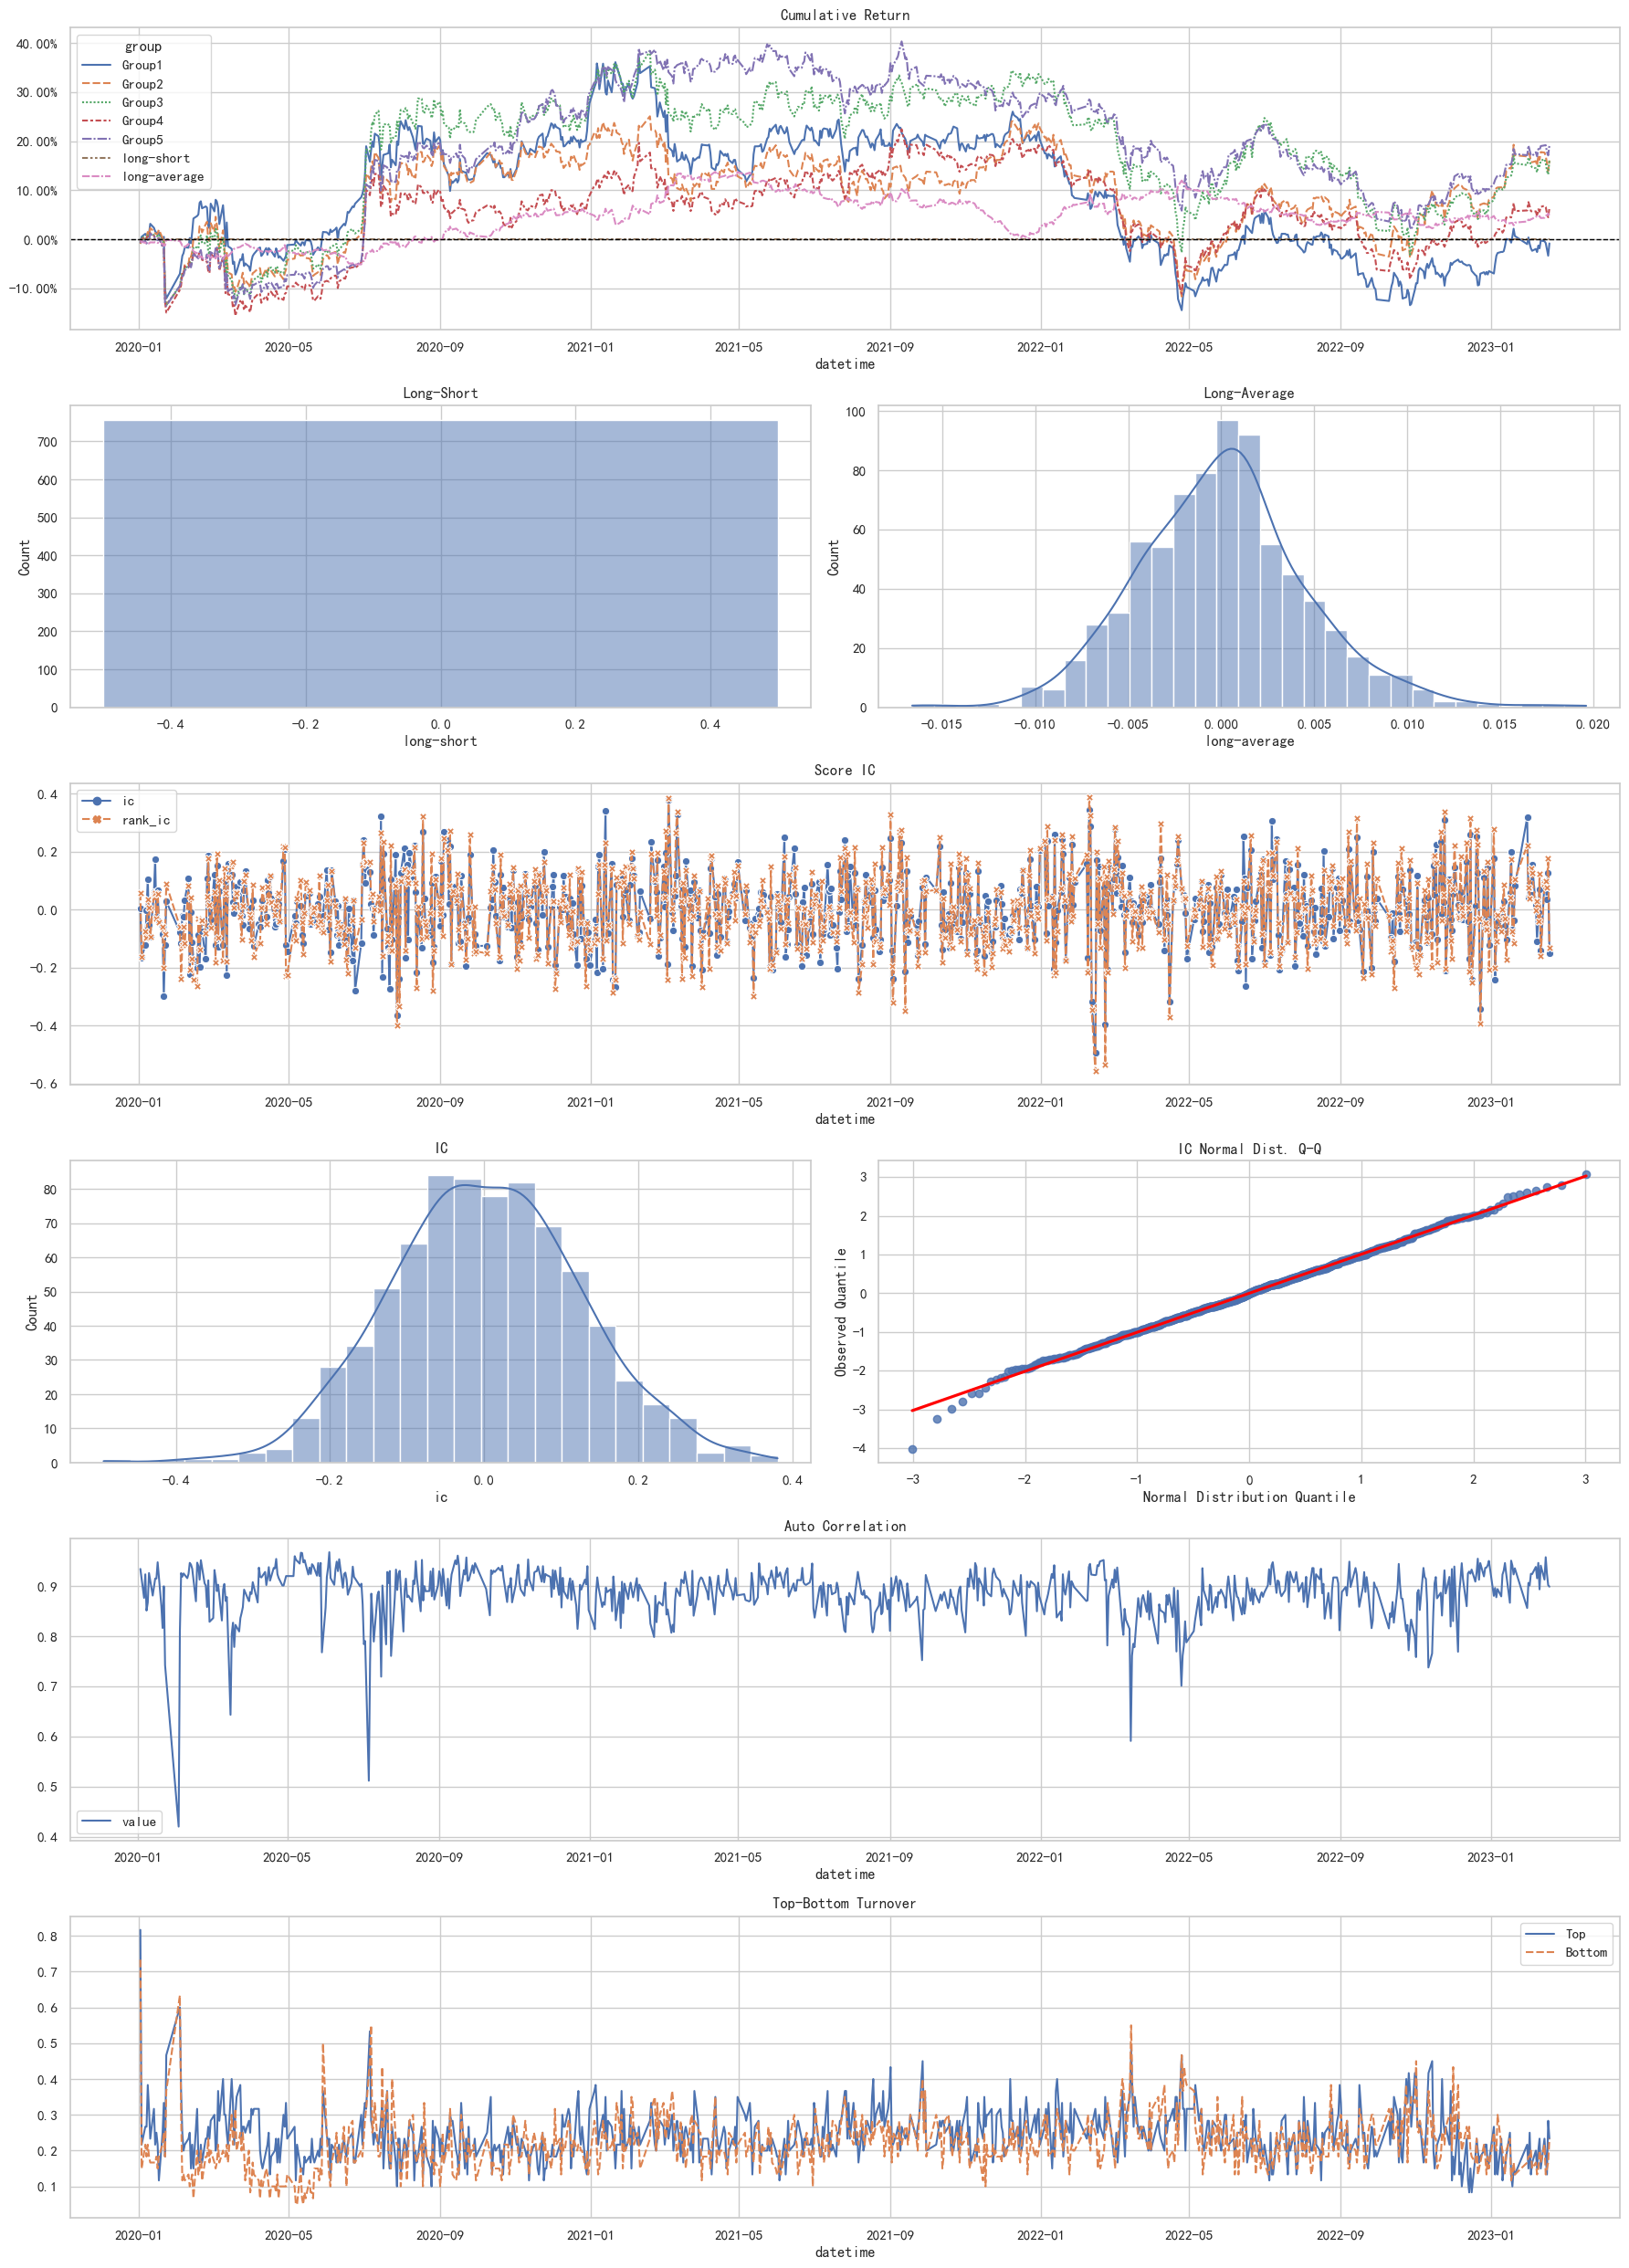

In [22]:
model_performance_graph(pred_label_df, duplicates='drop')

## 回测表现

In [23]:
report_normal_1day_df: pd.DataFrame = recorder.load_object(
    "portfolio_analysis/report_normal_1day.pkl")

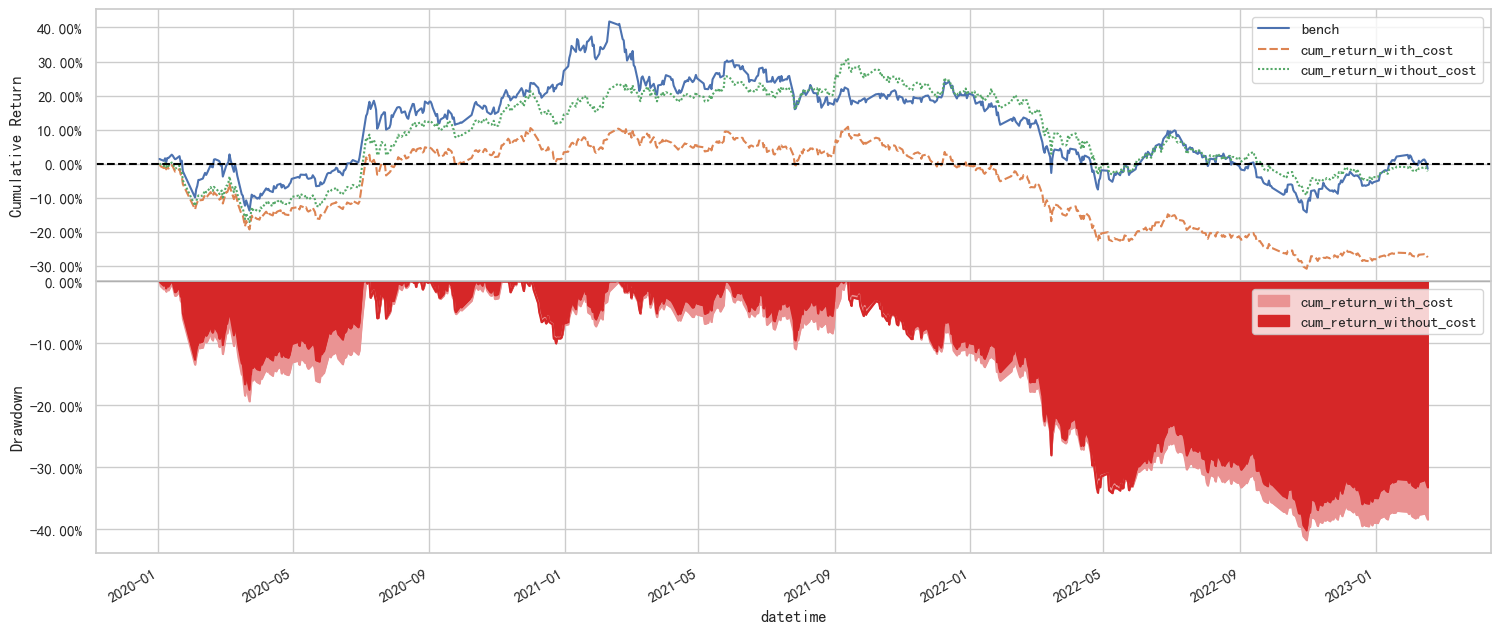

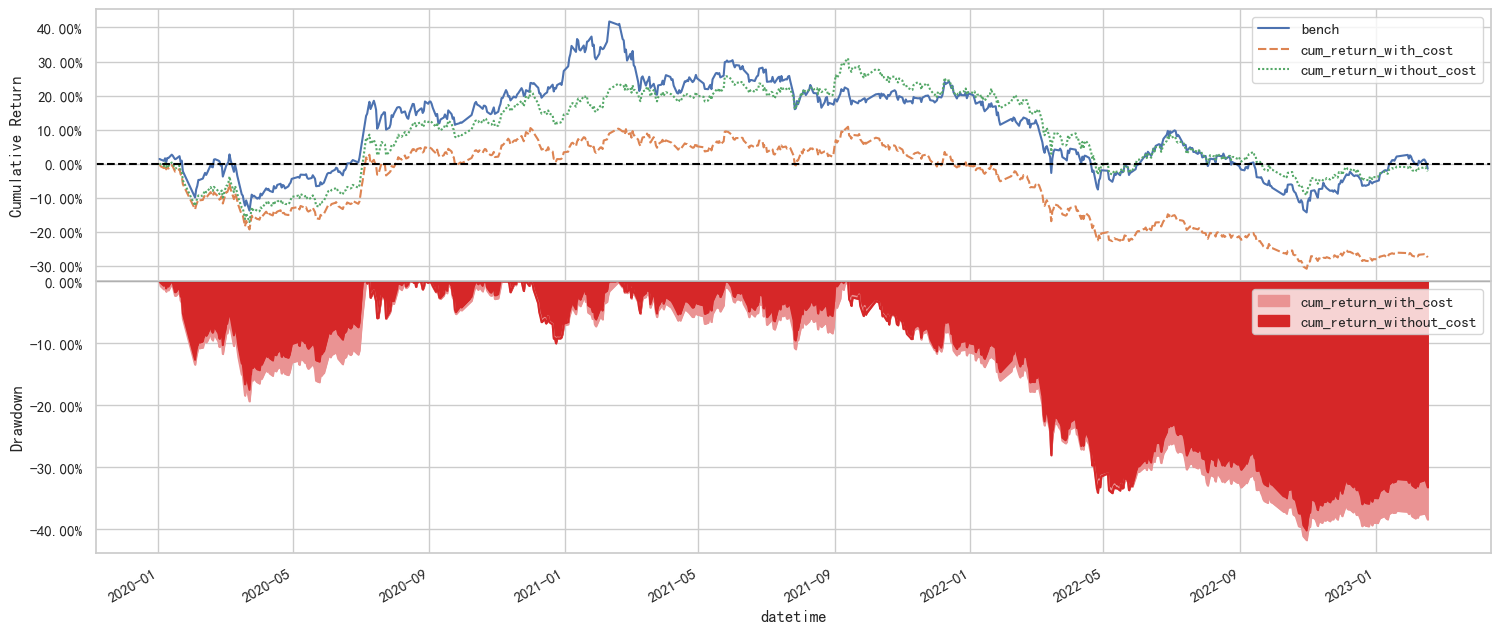

In [24]:
report_graph(report_normal_1day_df)